<a href="https://colab.research.google.com/github/SpicyMip/IQGA_SCP/blob/main/informe_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preinforme: Introducción a la Computación Cuántica
## Implementación de un Algoritmo Genético Cuántico (IQGA) para el Set Cover Problem (SCP)

**Integrantes:**
* Martín Pino
* Felipe Nuñez
* José Manuel Castro

## Descripción del problema

El problema abordado en este proyecto es el **Problema de Cobertura de Conjuntos** (Set Cover Problem, o SCP), clasificado como uno de los problemas clásicos de optimización combinatoria NP-hard de Karp.

Dado un "universo" de $U$ elementos y una colección $S$ de subconjuntos de $U$, donde cada subconjunto $s \in S$ tiene un costo asociado $c(s)$, el objetivo del SCP es encontrar una subcolección $S' \subseteq S$ tal que la unión de los conjuntos en $S'$ cubra todos los elementos de $U$, y cuyo costo total (la suma de los costos de los conjuntos en $S'$) sea minimizado.

## Enfoque: IQGA Multi-Variante con Simulación MPS

Para abordar la complejidad computacional y las limitaciones de memoria de la simulación cuántica en instancias grandes (OR-Library), esta implementación propone un Marco de Algoritmo Genético Cuántico Mejorado (IQGA) que se bifurca en tres estrategias de evolución (Memetic, Chaotic, Adaptive).

A diferencia de los enfoques cuánticos puros, este sistema utiliza una arquitectura híbrida que integra:

- Simulación Cuántica por Bloques (MPS): Para superar la barrera del número de qubits, las variables se dividen en N grupos y se simulan utilizando Matrix Product States (a través de AerSimulator), permitiendo manejar correlaciones cuánticas en instancias de alta dimensionalidad.

- Reparación Estocástica Inteligente: Un mecanismo constructivo que garantiza la factibilidad de las soluciones colapsadas.
- Refinamiento Clásico (Local Search): Un operador de intercambio (Swap) para escapar de óptimos locales.

El rendimiento de estas variantes se contrasta con un Algoritmo Genético Clásico (GA) con reinicio masivo (sparse restart), sirviendo como línea base (baseline) para validar la ventaja cuántica.

## Componentes del Algoritmo y Representación

La arquitectura del IQGA adapta los conceptos evolutivos clásicos al paradigma de la computación cuántica variacional:

- Cromosoma (Vector de Ángulos θ): En lugar de bits, el genoma consiste en un vector de ángulos θ∈[0,π]m. Cada θj​ controla la amplitud de probabilidad de un qubit mediante una puerta RY​(θj​). El estado del sistema no es una solución única, sino una superposición de todas las posibles soluciones, cuya distribución de probabilidad evoluciona hacia el óptimo.

- Evaluación y Reparación (repair_and_evaluate_stochastic): Las mediciones cuánticas a menudo producen soluciones infactibles (no cubren todo el universo). El algoritmo implementa un decodificador híbrido robusto:

  - Construcción Greedy Estocástica: Si la solución es infactible, se añaden conjuntos basándose en una heurística de eficiencia (costo/nuevas_filas_cubiertas). Se introduce un factor randomness (ajustable) para evitar determinismo y diversificar la búsqueda.

  - Poda de Redundancia: Una vez factible, se eliminan conjuntos redundantes (aquellos que, al quitarse, no rompen la cobertura) para minimizar el costo final.

- Operadores de Evolución Cuántica:

  - Entrelazamiento (Exploración): Dentro de cada grupo de simulación, se aplican puertas CNOT en cadena (vecinos más cercanos) para crear correlaciones cuánticas entre variables adyacentes.

  - Actualización (Aprendizaje): No se usa cruce clásico. Los ángulos θ se actualizan "girando" hacia la mejor solución binaria observada en los shots (muestreo). Se aplica una tasa de aprendizaje (lr) que varía según la variante (más agresiva en Chaotic, más suave en Memetic).

  - Mutación (Jitter y Reset): Se aplica ruido gaussiano (Jitter) a los ángulos para prevenir convergencia prematura.

- Búsqueda Local (local_search_swap): Un componente memético crucial. Intenta mejorar una solución válida intercambiando una columna seleccionada por otra no seleccionada que mantenga la cobertura pero reduzca el costo global (Swap).

Dificultades Enfrentadas y Soluciones Implementadas

Durante el desarrollo y la experimentación con las instancias de la OR-Library (ej. scp41, scp57, entre otras), surgieron desafíos críticos que moldearon la estructura final del código:

1. Escalabilidad de la Simulación Cuántica (El problema de los Qubits):
    - Dificultad: Simular circuitos de cientos de qubits (necesarios para instancias reales de SCP) es imposible con vectores de estado completos debido al crecimiento exponencial de la memoria RAM (2^N).
    - Solución en Código: Se implementó la función run_quantum_group. El problema se descompone en grupos de variables (ej. 20 grupos). Se utiliza el simulador AerSimulator con el método matrix_product_state (MPS), lo que permite una simulación eficiente de entrelazamiento local sin requerir memoria exponencial. Esto habilita la ejecución en instancias grandes (ej. 1000 columnas).

2. Estancamiento en Óptimos Locales Profundos

    - Dificultad: El algoritmo tendía a converger rápidamente a soluciones subóptimas y, debido a la naturaleza de la actualización de ángulos (que empuja θ a 0 o π), perdía la capacidad de explorar nuevas áreas ("congelamiento").

    - Solución (Variantes del Algoritmo): Se diseñaron tres estrategias para combatir esto:

        - IQGA Caótico (run_chaotic_iqga): Introduce ruido constante (jitter) en los ángulos y activa un mecanismo de "Catástrofe" cuando detecta estancamiento. La catástrofe elimina forzosamente el 10-15% de las columnas activas y aleatoriza una gran parte de los ángulos θ, forzando un reinicio desde una zona diferente.

        - IQGA Adaptativo (run_adaptive_iqga): Implementa una máquina de estados finitos. Comienza en modo Memético (refinamiento); si se estanca, cambia a modo Caótico (alta entropía); si el estancamiento persiste, ejecuta un Reset total.

3. Falsos Positivos en Factibilidad
    - Dificultad: En versiones previas, la reparación greedy a veces fallaba en casos de borde o la poda eliminaba columnas críticas, retornando costos bajos pero soluciones inválidas.
    - Solución: Se reescribió la función repair_and_evaluate_stochastic para incluir una doble verificación. Antes de retornar el costo, se calcula n_uncovered. Si n_uncovered > 0, se aplica una penalización masiva (cost + 10000 * n_uncovered), asegurando que el algoritmo nunca aprenda de soluciones infactibles.

4. Balance entre Tiempo de Cómputo y Calidad

    - Dificultad: La evaluación híbrida (reparación + búsqueda local) es costosa computacionalmente si se aplica a cada shot de la simulación cuántica.

    - Solución: Se aplica un filtrado elitista en la lectura de los shots. Solo se reparan y optimizan los top-3 o top-5 bitstrings más frecuentes (o probables) retornados por el simulador cuántico, reduciendo drásticamente el tiempo de CPU por generación sin sacrificar la calidad de la guía evolutiva.

In [ ]:
!pip install qiskit qiskit-aer requests --quiet
from __future__ import annotations
import argparse, csv, time, math, random, requests, os
from dataclasses import dataclass
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.0 MB/s eta 0:00:00


In [ ]:
@dataclass
class SCPInstance:
    A: np.ndarray   # Matriz de incidencia (Filas x Columnas)
    c: np.ndarray   # Vector de costos
    name: str       # Nombre de la instancia

    @property
    def n_elems(self): return self.A.shape[0]
    @property
    def n_sets(self): return self.A.shape[1]

def load_or_library_instance(url_or_path: str) -> SCPInstance:
    """
    Descarga (si es URL) y parsea una instancia SCP en formato Beasley (OR-Library).
    Formato estándar:
      - Linea 1: num_filas num_columnas
      - Bloque Costos: Costo de cada columna j
      - Bloque Cobertura: Para cada fila i: num_cols_que_cubren col_idx1 col_idx2 ...
    """
    if url_or_path.startswith("http"):
        filename = url_or_path.split("/")[-1]
        if not os.path.exists(filename):
            print(f"Descargando {filename} desde OR-Library...")
            response = requests.get(url_or_path)
            with open(filename, 'wb') as f:
                f.write(response.content)
        path = filename
    else:
        path = url_or_path

    with open(path, 'r') as f:
        tokens = f.read().split()
        iterator = iter(tokens)

    try:
        n_rows = int(next(iterator))
        n_cols = int(next(iterator))
        c = np.array([float(next(iterator)) for _ in range(n_cols)])
        A = np.zeros((n_rows, n_cols), dtype=bool)
        for i in range(n_rows):
            num_covering_sets = int(next(iterator))
            for _ in range(num_covering_sets):
                col_idx = int(next(iterator))
                A[i, col_idx - 1] = True

        print(f"Instancia '{path}' cargada: {n_rows} filas x {n_cols} columnas.")
        return SCPInstance(A=A, c=c, name=path)

    except StopIteration:
        raise ValueError("El archivo de instancia está incompleto o corrupto.")

In [ ]:
# ==========================================================
# 2. Motor de Simulación Eficiente (MPS)
# ==========================================================
def get_mps_simulator(bond_dim=64):
    """
    Simulador MPS acelerado por GPU (NVIDIA cuQuantum/CUDA).
    """
    mps_options = {
        "method": "matrix_product_state",
        "matrix_product_state_max_bond_dimension": bond_dim,
        "matrix_product_state_truncation_threshold": 1e-16,
    }

    try:
        sim = AerSimulator(**mps_options)
        return sim
    except Exception as e:
        return AerSimulator(**mps_options)

In [ ]:
def repair_and_evaluate(sub_solution, group_indices, context_vector, instance):
    """
    Evalúa integrando la sub-solución en el contexto global y reparando.
    """
    full_solution = context_vector.copy()
    if len(sub_solution) > 0:
        full_solution[group_indices] = sub_solution

    # --- Reparación Greedy (Híbrida) [cite: 217-227] ---
    covered = (instance.A[:, full_solution.astype(bool)]).any(axis=1)
    uncovered_rows = np.where(~covered)[0]

    if len(uncovered_rows) > 0:
        candidates = np.where(full_solution == 0)[0]
        while len(uncovered_rows) > 0 and len(candidates) > 0:
            # Heurística: Costo / (Filas nuevas cubiertas)
            sub_A = instance.A[uncovered_rows][:, candidates]
            gain = sub_A.sum(axis=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                efficiency = instance.c[candidates] / (gain + 1e-9)

            best_idx_local = np.argmin(efficiency)
            best_col = candidates[best_idx_local]

            full_solution[best_col] = 1

            new_covered = instance.A[uncovered_rows, best_col]
            uncovered_rows = uncovered_rows[~new_covered]
            candidates = candidates[candidates != best_col]

    total_cost = np.sum(full_solution * instance.c)
    return total_cost, full_solution


def check_feasibility(solution, instance):
    """Verifica si la solución cubre TODAS las filas."""
    if len(solution) == 0: return False
    # Multiplicación matricial booleana: A * x > 0
    covered_rows = (instance.A[:, solution.astype(bool)]).any(axis=1)
    return covered_rows.all()

def repair_and_evaluate_stochastic(sub_solution, group_indices, context_vector, instance, randomness=0.0):
    """
    Versión CORREGIDA Y ROBUSTA.
    Garantiza que no se devuelvan soluciones infactibles con costos falsamente bajos.
    """
    full_solution = context_vector.copy()
    if len(sub_solution) > 0:
        full_solution[group_indices] = sub_solution

    # ---------------------------------------------------------
    # 1. FASE CONSTRUCTIVA (Reparación Greedy)
    # ---------------------------------------------------------
    covered = (instance.A[:, full_solution.astype(bool)]).any(axis=1)
    uncovered_rows_indices = np.where(~covered)[0]

    # Solo entramos si hay algo que reparar
    if len(uncovered_rows_indices) > 0:
        # Candidatos: columnas que no están en la solución
        candidates = np.where(full_solution == 0)[0]

        while len(uncovered_rows_indices) > 0 and len(candidates) > 0:
            # Submatriz: solo filas no cubiertas y columnas candidatas
            sub_A = instance.A[uncovered_rows_indices][:, candidates]

            # Ganancia: cuántas de las filas NO CUBIERTAS cubre cada candidato
            gain = sub_A.sum(axis=0)

            # Filtramos candidatos que no aportan nada (gain 0) para no dividir por cero
            useful_candidates_mask = gain > 0

            if not useful_candidates_mask.any():
                # Ningún candidato restante puede cubrir las filas que faltan.
                # El algoritmo está atascado en una solución infactible.
                break

            # Filtramos los arrays para trabajar solo con útiles
            valid_candidates = candidates[useful_candidates_mask]
            valid_gain = gain[useful_candidates_mask]
            valid_costs = instance.c[valid_candidates]

            # Eficiencia: Costo por fila nueva cubierta (menor es mejor)
            efficiency = valid_costs / valid_gain

            # Selección Estocástica o Greedy
            if len(valid_candidates) >= 3 and randomness > 0 and np.random.rand() < randomness:
                # Top 3
                k = min(3, len(efficiency))
                # indices de los k menores en 'efficiency'
                top_k_local_indices = np.argpartition(efficiency, k-1)[:k]
                chosen_local_idx = np.random.choice(top_k_local_indices)
            else:
                # El mejor absoluto
                chosen_local_idx = np.argmin(efficiency)

            best_col = valid_candidates[chosen_local_idx]

            # Aplicar cambio
            full_solution[best_col] = 1

            # Actualizar filas no cubiertas (CRÍTICO: recalcular correctamente)
            # Verificamos qué filas de las que FALTABAN cubre esta nueva columna
            rows_covered_by_new = instance.A[uncovered_rows_indices, best_col]
            # Mantenemos solo las que siguen siendo False (no cubiertas)
            uncovered_rows_indices = uncovered_rows_indices[~rows_covered_by_new]

            # Quitar el elegido de los candidatos
            candidates = candidates[candidates != best_col]

    # ---------------------------------------------------------
    # 2. VERIFICACIÓN DE FACTIBILIDAD (Error Crítico 3 Solucionado)
    # ---------------------------------------------------------
    # Recalculamos globalmente para estar 100% seguros
    final_covered = (instance.A[:, full_solution.astype(bool)]).any(axis=1)
    n_uncovered = np.sum(~final_covered)

    current_cost = np.sum(full_solution * instance.c)

    if n_uncovered > 0:
        # PENALIZACIÓN: Costo real + Penalización gigante.
        # Esto evita que el GA seleccione esta solución "tramposa".
        penalty = 10000.0 * n_uncovered
        return current_cost + penalty, full_solution

    # ---------------------------------------------------------
    # 3. FASE DE PODA (Redundancy Elimination) - Solo si es factible
    # ---------------------------------------------------------
    # Ahora es seguro podar porque sabemos que partimos de una solución válida.
    if np.sum(full_solution) > 0:
        active_cols = np.where(full_solution == 1)[0]
        # Intentar quitar primero las columnas más caras
        active_cols = active_cols[np.argsort(-instance.c[active_cols])]

        for col in active_cols:
            # Simulamos quitar la columna
            full_solution[col] = 0

            # OPTIMIZACIÓN DEL ERROR 1:
            # Solo necesitamos verificar si las filas que ESA columna cubría
            # siguen estando cubiertas por el resto de la solución.
            rows_covered_by_col = np.where(instance.A[:, col])[0]

            # Submatriz: filas específicas x columnas activas restantes
            sub_check = instance.A[rows_covered_by_col][:, full_solution.astype(bool)]

            # Si alguna de esas filas queda con suma 0, entonces NO están cubiertas
            is_still_feasible = sub_check.any(axis=1).all()

            if not is_still_feasible:
                full_solution[col] = 1 # Revertir cambio, era necesaria

    # Costo final recalculado post-poda
    final_cost = np.sum(full_solution * instance.c)
    return final_cost, full_solution

In [ ]:
def run_quantum_group(n_qubits, thetas, simulator, shots=100, seed=None):
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.ry(float(thetas[i]), i)

    for i in range(n_qubits - 1):
        qc.cx(i, i+1)
    qc.measure_all()
    qc_t = transpile(qc, basis_gates=['ry', 'cx', 'measure'], optimization_level=0)
    result = simulator.run(qc_t, shots=shots, seed_simulator=seed).result()
    return result.get_counts()

In [ ]:
def local_search_swap(solution, instance):
    """
    Intenta mejorar la solución intercambiando una columna seleccionada
    por otra no seleccionada que cubra lo mismo (o más) a menor costo.
    """
    current_sol = solution.copy()
    current_cost = np.sum(current_sol * instance.c)
    selected_indices = np.where(current_sol == 1)[0]
    np.random.shuffle(selected_indices)

    improved = False

    for col_out in selected_indices:
        current_sol[col_out] = 0
        rows_covered_by_out = np.where(instance.A[:, col_out])[0]
        sub_A = instance.A[rows_covered_by_out][:, current_sol.astype(bool)]
        coverage_counts = sub_A.sum(axis=1)
        critical_rows_local_indices = np.where(coverage_counts == 0)[0]
        if len(critical_rows_local_indices) == 0:
            current_cost -= instance.c[col_out]
            improved = True
            continue

        critical_rows = rows_covered_by_out[critical_rows_local_indices]
        first_crit_row = critical_rows[0]
        candidates = np.where(instance.A[first_crit_row, :] & (current_sol == 0))[0]

        best_swap = -1
        min_swap_cost = instance.c[col_out]

        for col_in in candidates:
            if instance.c[col_in] >= min_swap_cost:
                continue
            covers_all = True
            if len(critical_rows) > 1:
                if not instance.A[critical_rows[1:], col_in].all():
                    covers_all = False

            if covers_all:
                best_swap = col_in
                min_swap_cost = instance.c[col_in]

        if best_swap != -1:
            current_sol[best_swap] = 1
            current_cost = current_cost - instance.c[col_out] + instance.c[best_swap]
            improved = True
        else:
            current_sol[col_out] = 1

    return current_cost, current_sol

In [ ]:
def run_memetic_iqga(instance, n_groups=20, generations=60, shots=512, seed=None):
    """
    IQGA Híbrido con Búsqueda Local (Memético).

    Args:
        instance: La instancia del problema SCP.
        n_groups: Número de grupos para dividir las variables.
        generations: Número de generaciones.
        shots: Número de mediciones cuánticas.
        seed: Semilla para reproducibilidad (opcional).
    """

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    n_vars = instance.n_sets
    simulator = get_mps_simulator()

    context = np.zeros(n_vars, dtype=int)

    best_cost, best_sol = repair_and_evaluate_stochastic(
        np.array([]), np.array([]), context, instance, randomness=0.3
    )

    best_cost, best_sol = local_search_swap(best_sol, instance)

    context = best_sol.copy()
    best_sol_snapshot = context.copy()

    thetas = np.full(n_vars, np.pi/2)
    history = []
    stagnation_counter = 0
    patience = 5

    print(f"--- Memetic IQGA (Quantum + Swap Local Search) ---")
    print(f"Costo Inicial (Optimizado): {best_cost:.2f}")

    for gen in range(generations):
        current_randomness = 0.2 * (1 - gen/generations)

        indices = np.arange(n_vars)
        np.random.shuffle(indices)
        groups = np.array_split(indices, n_groups)

        improved_in_gen = False

        for i, group_idx in enumerate(groups):
            if len(group_idx) == 0: continue
            group_sim_seed = None
            if seed is not None:
                group_sim_seed = seed + (gen * 1000) + i

            counts = run_quantum_group(
                len(group_idx),
                thetas[group_idx],
                simulator,
                shots,
                seed=group_sim_seed
            )

            sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:3]
            best_group_sol = None

            for bitstring, _ in sorted_counts:
                sub_sol = np.array([int(b) for b in bitstring[::-1]])
                if len(sub_sol) != len(group_idx): continue

                cost, full_rep = repair_and_evaluate_stochastic(
                    sub_sol, group_idx, context, instance, randomness=current_randomness
                )

                if cost <= best_cost * 1.05:
                     cost_ls, sol_ls = local_search_swap(full_rep, instance)
                     if cost_ls < cost:
                         cost = cost_ls
                         full_rep = sol_ls

                if cost < best_cost:
                    best_cost = cost
                    best_sol = full_rep.copy()
                    best_sol_snapshot = full_rep.copy()
                    context = full_rep.copy()
                    best_group_sol = sub_sol
                    improved_in_gen = True
                    stagnation_counter = 0
                    print(f"   >>> Nuevo Récord: {best_cost:.2f} (Gen {gen})")

                if best_group_sol is None: best_group_sol = sub_sol

            if best_group_sol is not None:
                lr = 0.05
                current_thetas = thetas[group_idx]
                for k, val in enumerate(best_group_sol):
                    target = 0.02 if val == 0 else (np.pi - 0.02)
                    if current_thetas[k] < target: current_thetas[k] += lr
                    else: current_thetas[k] -= lr
                thetas[group_idx] = current_thetas

        history.append(best_cost)

        if not improved_in_gen:
            stagnation_counter += 1

        if stagnation_counter >= patience:
            print(f"   [!] Estancamiento. Perturbando contexto...")
            active_cols = np.where(context == 1)[0]
            if len(active_cols) > 0:
                cols_to_remove = np.random.choice(active_cols, min(3, len(active_cols)), replace=False)
                context[cols_to_remove] = 0
                mask = np.random.rand(n_vars) < 0.3
                thetas[mask] = np.random.uniform(0.1, np.pi-0.1, size=np.sum(mask))

                _, context = repair_and_evaluate_stochastic(
                    np.array([]), np.array([]), context, instance, randomness=0.5
                )
            stagnation_counter = 0

        if (gen+1) % 10 == 0:
            print(f"Gen {gen+1}: {best_cost:.2f}")

    return best_cost, best_sol_snapshot, history

In [ ]:
def run_chaotic_iqga(instance, n_groups=20, generations=60, shots=512, seed=None):
    """
    Versión diseñada para ser inestable y escapar de óptimos locales fuertes.
    Introduce ruido constante y reinicios agresivos.

    Args:
        instance: Instancia del problema.
        n_groups: Número de grupos.
        generations: Número de generaciones.
        shots: Shots cuánticos.
        seed: Semilla para reproducibilidad (opcional).
    """

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    n_vars = instance.n_sets
    simulator = get_mps_simulator()

    context = np.zeros(n_vars, dtype=int)

    best_cost, context = repair_and_evaluate_stochastic(np.array([]), np.array([]), context, instance, randomness=0.5)
    best_cost, context = local_search_swap(context, instance)

    best_solution_global = context.copy()
    thetas = np.full(n_vars, np.pi/2)

    history = []
    stagnation_counter = 0
    patience = 3

    print(f"--- Chaotic IQGA (High Entropy Mode) ---")
    print(f"Costo Inicial: {best_cost:.2f}")

    for gen in range(generations):
        current_randomness = max(0.05, 0.4 * (1 - gen/generations))

        indices = np.arange(n_vars)
        np.random.shuffle(indices)
        groups = np.array_split(indices, n_groups)

        improved_in_gen = False

        for i, group_idx in enumerate(groups):
            if len(group_idx) == 0: continue

            jitter = np.random.uniform(-0.02, 0.02, size=len(group_idx))
            thetas[group_idx] = np.clip(thetas[group_idx] + jitter, 0.01, np.pi-0.01)

            group_sim_seed = None
            if seed is not None:
                group_sim_seed = seed + (gen * 10000) + i

            counts = run_quantum_group(
                len(group_idx),
                thetas[group_idx],
                simulator,
                shots,
                seed=group_sim_seed
            )

            sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
            best_group_sol = None

            for bitstring, _ in sorted_counts:
                sub_sol = np.array([int(b) for b in bitstring[::-1]])
                if len(sub_sol) != len(group_idx): continue

                cost, full_rep = repair_and_evaluate_stochastic(
                    sub_sol, group_idx, context, instance, randomness=current_randomness
                )

                if cost <= best_cost * 1.02:
                     cost_ls, sol_ls = local_search_swap(full_rep, instance)
                     if cost_ls < cost:
                         cost = cost_ls
                         full_rep = sol_ls

                if cost < best_cost:
                    best_cost = cost
                    best_solution_global = full_rep.copy()
                    context = full_rep.copy()
                    best_group_sol = sub_sol
                    improved_in_gen = True
                    stagnation_counter = 0
                    print(f"   Récord Caótico: {best_cost:.2f} (Gen {gen})")

                if best_group_sol is None and cost < best_cost * 1.1:
                    best_group_sol = sub_sol

            if best_group_sol is not None:
                lr = 0.10
                current_thetas = thetas[group_idx]
                for k, val in enumerate(best_group_sol):
                    target = 0.05 if val == 0 else (np.pi - 0.05)
                    if current_thetas[k] < target: current_thetas[k] += lr
                    else: current_thetas[k] -= lr
                thetas[group_idx] = current_thetas

        history.append(best_cost)
        if not improved_in_gen: stagnation_counter += 1

        if stagnation_counter >= patience:
            print(f"   [!] ESTANCAMIENTO DETECTADO. INICIANDO CATÁSTROFE...")
            active_cols = np.where(context == 1)[0]
            if len(active_cols) > 0:
                n_destroy = max(1, int(len(active_cols) * 0.10))
                cols_to_remove = np.random.choice(active_cols, n_destroy, replace=False)
                context[cols_to_remove] = 0

            mask_reset = np.random.rand(n_vars) < 0.70
            thetas[mask_reset] = np.random.uniform(0.1, np.pi-0.1, size=np.sum(mask_reset))

            _, context = repair_and_evaluate_stochastic(
                np.array([]), np.array([]), context, instance, randomness=0.8
            )

            stagnation_counter = 0

        if (gen+1) % 5 == 0:
            print(f"Gen {gen+1}: {best_cost:.2f}")

    return best_cost, best_solution_global, history

In [ ]:
def run_adaptive_iqga(instance, n_groups=20, generations=60, shots=512, seed=None):
    """
    Algoritmo Adaptativo que alterna dinámicamente entre
    Estrategia Memética (Refinamiento) y Caótica (Exploración)
    basado en el estado de convergencia.

    Args:
        instance: Instancia del problema SCP.
        n_groups: Divisiones de variables.
        generations: Total de generaciones.
        shots: Mediciones cuánticas.
        seed: Semilla para reproducibilidad (opcional).
    """

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    n_vars = instance.n_sets
    simulator = get_mps_simulator()

    context = np.zeros(n_vars, dtype=int)
    best_cost, context = repair_and_evaluate_stochastic(np.array([]), np.array([]), context, instance, randomness=0.3)
    best_cost, context = local_search_swap(context, instance)

    best_solution_global = context.copy()

    thetas = np.full(n_vars, np.pi/2)
    history = []
    stagnation_counter = 0
    THRESH_CHAOS = 2
    THRESH_DISASTER = 6

    print(f"--- Adaptive IQGA (Smart Hybrid) ---")
    print(f"Costo Inicial: {best_cost:.2f}")

    for gen in range(generations):
        if stagnation_counter < THRESH_CHAOS:
            mode = "MEMETIC"
            use_jitter = False
            use_swap = True
            randomness = 0.1
            lr = 0.0
            status_tag = "[MEMETIC]"
        elif stagnation_counter < THRESH_DISASTER:
            mode = "CHAOTIC"
            use_jitter = True
            use_swap = False
            randomness = 0.4
            lr = 0.12
            status_tag = "[CHAOTIC]"
        else:
            mode = "RESET"
            status_tag = "[RESET]"

        indices = np.arange(n_vars)
        np.random.shuffle(indices)
        groups = np.array_split(indices, n_groups)

        improved_in_gen = False

        if mode != "RESET":

            for i, group_idx in enumerate(groups):
                if len(group_idx) == 0: continue

                if use_jitter:
                    jitter = np.random.uniform(-0.03, 0.03, size=len(group_idx))
                    thetas[group_idx] = np.clip(thetas[group_idx] + jitter, 0.01, np.pi-0.01)

                group_sim_seed = None
                if seed is not None:
                    group_sim_seed = seed + (gen * 100000) + i

                counts = run_quantum_group(
                    len(group_idx),
                    thetas[group_idx],
                    simulator,
                    shots,
                    seed=group_sim_seed
                )

                sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:4]

                best_group_sol = None

                for bitstring, _ in sorted_counts:
                    sub_sol = np.array([int(b) for b in bitstring[::-1]])
                    if len(sub_sol) != len(group_idx): continue

                    cost, full_rep = repair_and_evaluate_stochastic(
                        sub_sol, group_idx, context, instance, randomness=randomness
                    )

                    if use_swap and cost <= best_cost * 1.05:
                         cost_ls, sol_ls = local_search_swap(full_rep, instance)
                         if cost_ls < cost:
                             cost = cost_ls
                             full_rep = sol_ls

                    if cost < best_cost:
                        best_cost = cost
                        best_solution_global = full_rep.copy()
                        context = full_rep.copy()
                        best_group_sol = sub_sol
                        improved_in_gen = True
                        stagnation_counter = 0
                        print(f"   {status_tag} Nuevo Record: {best_cost:.2f}")

                    if best_group_sol is None: best_group_sol = sub_sol

                if best_group_sol is not None:
                    current_thetas = thetas[group_idx]
                    for k, val in enumerate(best_group_sol):
                        target = 0.05 if val == 0 else (np.pi - 0.05)
                        if current_thetas[k] < target: current_thetas[k] += lr
                        else: current_thetas[k] -= lr
                    thetas[group_idx] = current_thetas

        history.append(best_cost)
        if not improved_in_gen: stagnation_counter += 1

        if mode == "RESET":
            print(f"   [RESET] SISTEMA CRITICO. EJECUTANDO REINICIO DUAL...")

            active_cols = np.where(context == 1)[0]
            if len(active_cols) > 0:
                n_kill = max(2, int(len(active_cols) * 0.15))
                cols_to_remove = np.random.choice(active_cols, n_kill, replace=False)
                context[cols_to_remove] = 0

            mask_reset = np.random.rand(n_vars) < 0.60
            thetas[mask_reset] = np.random.uniform(0.1, np.pi-0.1, size=np.sum(mask_reset))

            _, context = repair_and_evaluate_stochastic(
                np.array([]), np.array([]), context, instance, randomness=0.6
            )

            stagnation_counter = THRESH_CHAOS

        if (gen+1) % 5 == 0:
            print(f"Gen {gen+1} [{mode}]: {best_cost:.2f}")

    return best_cost, best_solution_global, history

In [ ]:
def run_classical_ga_sparse(instance, pop_size=50, generations=50, seed=None):
    """
    Implementa 'Massive Extinction/Restart': Si se estanca, reemplaza a la población mala.
    """

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    n_vars = instance.n_sets
    pop = (np.random.rand(pop_size, n_vars) < 0.05).astype(int)

    global_best = float('inf')
    history = []

    stagnation_counter = 0
    patience = 6

    print(f"--- GA Clásico (Con Reinicio Masivo) ---")

    for gen in range(generations):
        fitnesses = []
        repaired_pop = []

        improved = False

        for ind in pop:
            cost, rep_ind = repair_and_evaluate(np.array([]), np.array([]), ind, instance)
            fitnesses.append(cost)
            repaired_pop.append(rep_ind)
            if cost < global_best:
                global_best = cost
                improved = True
                stagnation_counter = 0

        if not improved:
            stagnation_counter += 1

        history.append(global_best)

        if stagnation_counter >= patience:
            print(f"   [!] GA Estancado (Gen {gen}). Reinicio Masivo de Población...")
            best_idx = np.argmin(fitnesses)
            elite = repaired_pop[best_idx].copy()

            pop = (np.random.rand(pop_size, n_vars) < 0.05).astype(int)
            pop[0] = elite

            stagnation_counter = 0
            continue

        new_pop = []
        best_idx = np.argmin(fitnesses)
        new_pop.append(repaired_pop[best_idx].copy())

        while len(new_pop) < pop_size:
            idxs = np.random.choice(pop_size, 3, replace=False)
            candidates_fits = [fitnesses[i] for i in idxs]
            winner_idx = idxs[np.argmin(candidates_fits)]

            parent1 = repaired_pop[winner_idx]
            parent2 = repaired_pop[np.random.randint(0, pop_size)]

            child = parent1.copy()
            mask = np.random.rand(n_vars) < 0.5
            child[mask] = parent2[mask]

            if np.random.rand() < 0.1:
                mut_mask = np.random.rand(n_vars) < 0.02
                child[mut_mask] = 1 - child[mut_mask]

            new_pop.append(child)

        pop = np.array(new_pop)

        if (gen+1) % 5 == 0:
            print(f"GA Gen {gen+1}: Costo {global_best:.2f}")

    return global_best, history

In [ ]:

# DICCIONARIO DE ÓPTIMOS

OPT_SCP = {
    "scp41": {"value": 429, "source": "Beasley 1990"},
    "scp42": {"value": 512, "source": "Beasley 1990"},
    "scp43": {"value": 516, "source": "Beasley 1990"},
    "scp44": {"value": 494, "source": "Beasley 1990"},
    "scp45": {"value": 512, "source": "Beasley 1990"},
    "scp46": {"value": 560, "source": "Beasley 1990"},
    "scp47": {"value": 430, "source": "Beasley 1990"},
    "scp48": {"value": 492, "source": "Beasley 1990"},
    "scp49": {"value": 641, "source": "Beasley 1990"},
    "scp50": {"value": 514, "source": "Beasley 1990"},

    # Unicost (Exactos)
    "scp51": {"value": 253, "source": "Grossman & Wool 1997"},
    "scp52": {"value": 302, "source": "Grossman & Wool 1997"},
    "scp53": {"value": 226, "source": "Grossman & Wool 1997"},
    "scp54": {"value": 242, "source": "Grossman & Wool 1997"},
    "scp55": {"value": 211, "source": "Grossman & Wool 1997"},
    "scp56": {"value": 213, "source": "Grossman & Wool 1997"},
    "scp57": {"value": 293, "source": "Grossman & Wool 1997"},
    "scp58": {"value": 288, "source": "Grossman & Wool 1997"},
    "scp59": {"value": 279, "source": "Grossman & Wool 1997"},
    "scp60": {"value": 265, "source": "Grossman & Wool 1997"},
    "scp61": {"value": 138, "source": "Grossman & Wool 1997"},
    "scp62": {"value": 137, "source": "Grossman & Wool 1997"},

    # A-series
    "scpa1": {"value": 253, "source": "Caprara et al. 2000"},
    "scpa2": {"value": 252, "source": "Caprara et al. 2000"},
    "scpa3": {"value": 232, "source": "Caprara et al. 2000"},
    "scpa4": {"value": 234, "source": "Caprara et al. 2000"},
    "scpa5": {"value": 236, "source": "Caprara et al. 2000"},

    # B-series
    "scpb1": {"value": 69, "source": "Caprara et al. 2000"},
    "scpb2": {"value": 76, "source": "Caprara et al. 2000"},
    "scpb3": {"value": 80, "source": "Caprara et al. 2000"},
    "scpb4": {"value": 79, "source": "Caprara et al. 2000"},
    "scpb5": {"value": 72, "source": "Caprara et al. 2000"},

    # C-series
    "scpc1": {"value": 227, "source": "Caprara et al. 2000"},
    "scpc2": {"value": 219, "source": "Caprara et al. 2000"},
    "scpc3": {"value": 243, "source": "Caprara et al. 2000"},
    "scpc4": {"value": 219, "source": "Caprara et al. 2000"},
    "scpc5": {"value": 215, "source": "Caprara et al. 2000"},

}


def get_gap(cost, bks):
    if bks is None or bks <= 0:
        return 0.0
    return ((cost - bks) / bks) * 100.0


def get_bks_from_filename(filename: str):
    """
    Extrae 'scpXX' o 'scpaX', etc. desde nombres como 'scp42.txt'
    """
    name = filename.lower().replace(".txt", "")
    return OPT_SCP.get(name, None)


In [ ]:
def print_solution_details(solution_vector, instance, algo_name="Algoritmo"):
    """
    Imprime los detalles técnicos de la solución para validación externa.
    """
    selected_indices_0 = np.where(solution_vector == 1)[0]
    selected_indices_1 = selected_indices_0 + 1

    real_cost = np.sum(solution_vector * instance.c)

    covered_mask = (instance.A[:, solution_vector.astype(bool)]).any(axis=1)
    is_feasible = covered_mask.all()

    num_missing = np.sum(~covered_mask)

    print(f"\nDETALLE DE SOLUCIÓN ({algo_name})")
    print(f"{'-'*40}")
    print(f"Estado:           {'FACTIBLE (Válida)' if is_feasible else 'INFACTIBLE (Inválida)'}")
    if not is_feasible:
        print(f"Filas sin cubrir: {num_missing}")
    print(f"Costo Calculado:  {real_cost}")
    print(f"Columnas Usadas:  {len(selected_indices_0)}")
    print(f"{'-'*40}")
    print("Lista de Columnas (Formato 1-based para OR-Library):")
    print(selected_indices_1.tolist())

    return is_feasible

# Benchmark General: Análisis de 11 Instancias

## Aviso Importante sobre el Tiempo de Ejecución:
La ejecución completa de este benchmark requiere entre 3 y 4 horas.

Para una validación rápida: Si se desea verificar la funcionalidad del código en menos tiempo, se puede redefinir la variable INSTANCIAS_OBJETIVO seleccionando únicamente una instancia (por ejemplo, ['scp41']).

Iniciando Benchmark con SEED=1764318086
Instancias: 11 archivos a procesar
Instancia 'scp41.txt' cargada: 200 filas x 1000 columnas.

Procesando: scp41 (200x1000) | BKS: 429
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 445.00
   >>> Nuevo Récord: 443.00 (Gen 0)
   >>> Nuevo Récord: 433.00 (Gen 0)
   [!] Estancamiento. Perturbando contexto...
Gen 10: 433.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 431.00 (Gen 14)
   [!] Estancamiento. Perturbando contexto...
Gen 20: 431.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 431.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 431.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 50: 431.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 60: 431.00
   [!] Estancamiento. Perturbando c

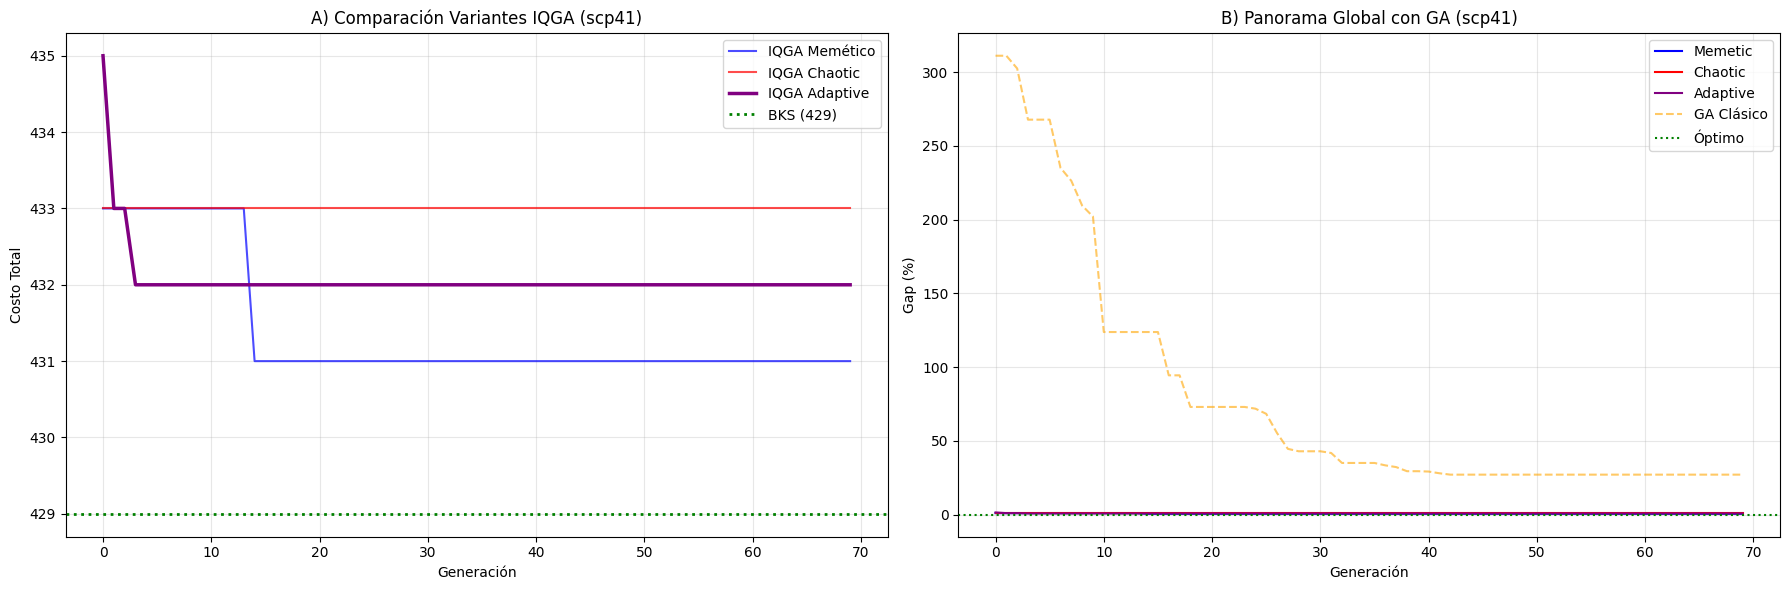

RESULTADOS FINALES PARA scp41:
   Memetic Gap:  0.47%  (Costo: 431.0)
   Chaotic Gap:  0.93%  (Costo: 433.0)
   Adaptive Gap: 0.70%  (Costo: 432.0)
   GA Gap:       27.04%  (Costo: 545.0)
--------------------------------------------------------------------------------
Descargando scp49.txt desde OR-Library...
Instancia 'scp49.txt' cargada: 200 filas x 1000 columnas.

Procesando: scp49 (200x1000) | BKS: 641
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 689.00
   >>> Nuevo Récord: 684.00 (Gen 0)
   >>> Nuevo Récord: 681.00 (Gen 0)
   >>> Nuevo Récord: 680.00 (Gen 3)
   >>> Nuevo Récord: 678.00 (Gen 6)
Gen 10: 678.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 678.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 673.00 (Gen 29)
Gen 30: 673.00
   >>> Nuevo Récord: 669.00 (Gen 30)
   >>> Nuevo Récord: 668.00 (Gen 30)
   >>> Nuevo Récord:

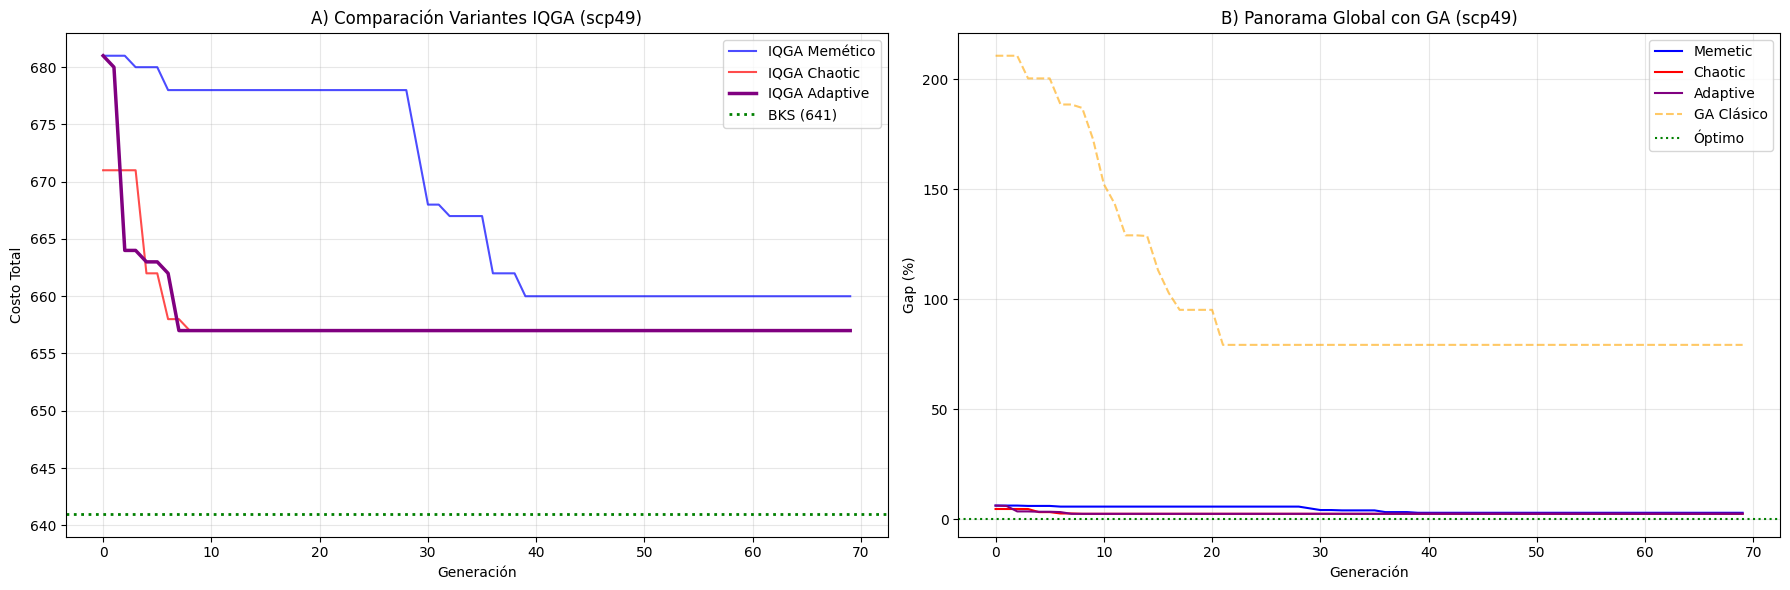

RESULTADOS FINALES PARA scp49:
   Memetic Gap:  2.96%  (Costo: 660.0)
   Chaotic Gap:  2.50%  (Costo: 657.0)
   Adaptive Gap: 2.50%  (Costo: 657.0)
   GA Gap:       79.25%  (Costo: 1149.0)
--------------------------------------------------------------------------------
Descargando scp53.txt desde OR-Library...
Instancia 'scp53.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp53 (200x2000) | BKS: 226
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 235.00
   >>> Nuevo Récord: 234.00 (Gen 4)
   [!] Estancamiento. Perturbando contexto...
Gen 10: 234.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 234.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 234.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 233.00 (Gen 35)
   >>> Nuevo Récord: 230.00 (Gen 37)
Gen 40: 230.00
   [!] Estancamiento. Perturbando contexto...
   [!] Esta

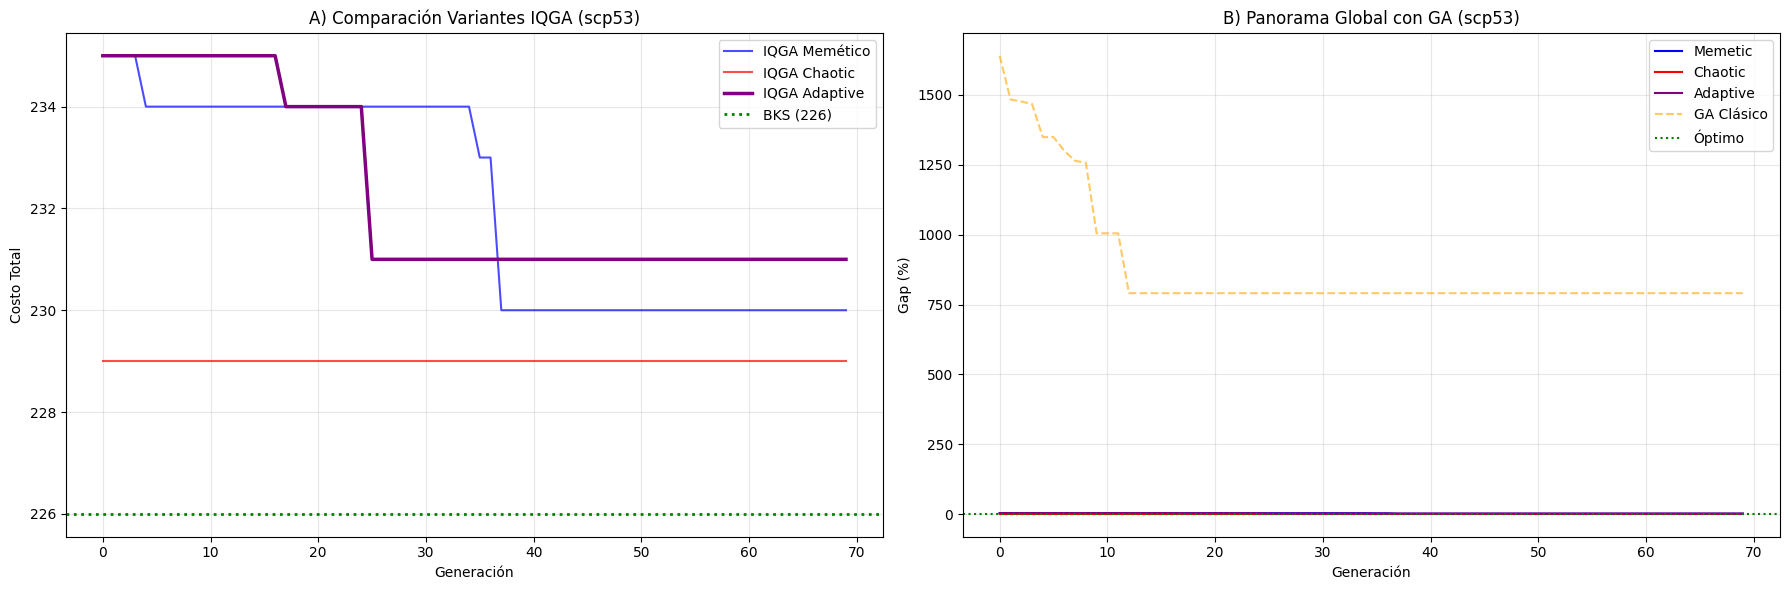

RESULTADOS FINALES PARA scp53:
   Memetic Gap:  1.77%  (Costo: 230.0)
   Chaotic Gap:  1.33%  (Costo: 229.0)
   Adaptive Gap: 2.21%  (Costo: 231.0)
   GA Gap:       790.71%  (Costo: 2013.0)
--------------------------------------------------------------------------------
Descargando scp57.txt desde OR-Library...
Instancia 'scp57.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp57 (200x2000) | BKS: 293
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 306.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 305.00 (Gen 6)
Gen 10: 305.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 301.00 (Gen 18)
   >>> Nuevo Récord: 296.00 (Gen 18)
Gen 20: 296.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 296.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 296.00
   [!] Est

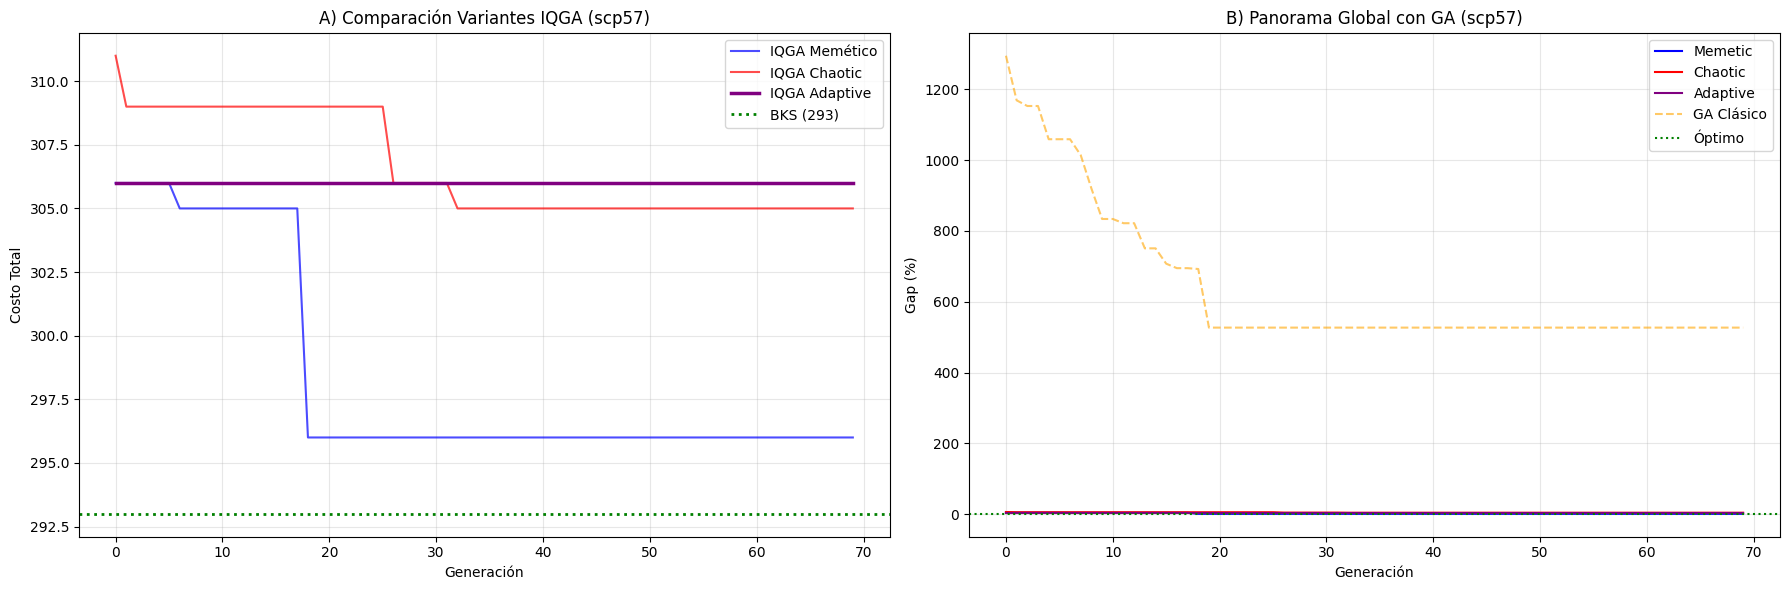

RESULTADOS FINALES PARA scp57:
   Memetic Gap:  1.02%  (Costo: 296.0)
   Chaotic Gap:  4.10%  (Costo: 305.0)
   Adaptive Gap: 4.44%  (Costo: 306.0)
   GA Gap:       526.96%  (Costo: 1837.0)
--------------------------------------------------------------------------------
Descargando scp61.txt desde OR-Library...
Instancia 'scp61.txt' cargada: 200 filas x 1000 columnas.

Procesando: scp61 (200x1000) | BKS: 138
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 147.00
   >>> Nuevo Récord: 146.00 (Gen 2)
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 145.00 (Gen 9)
Gen 10: 145.00
   >>> Nuevo Récord: 144.00 (Gen 10)
   [!] Estancamiento. Perturbando contexto...
Gen 20: 144.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 144.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 144.00
   [!] Estancamiento. Perturbando contexto...
   [!] Esta

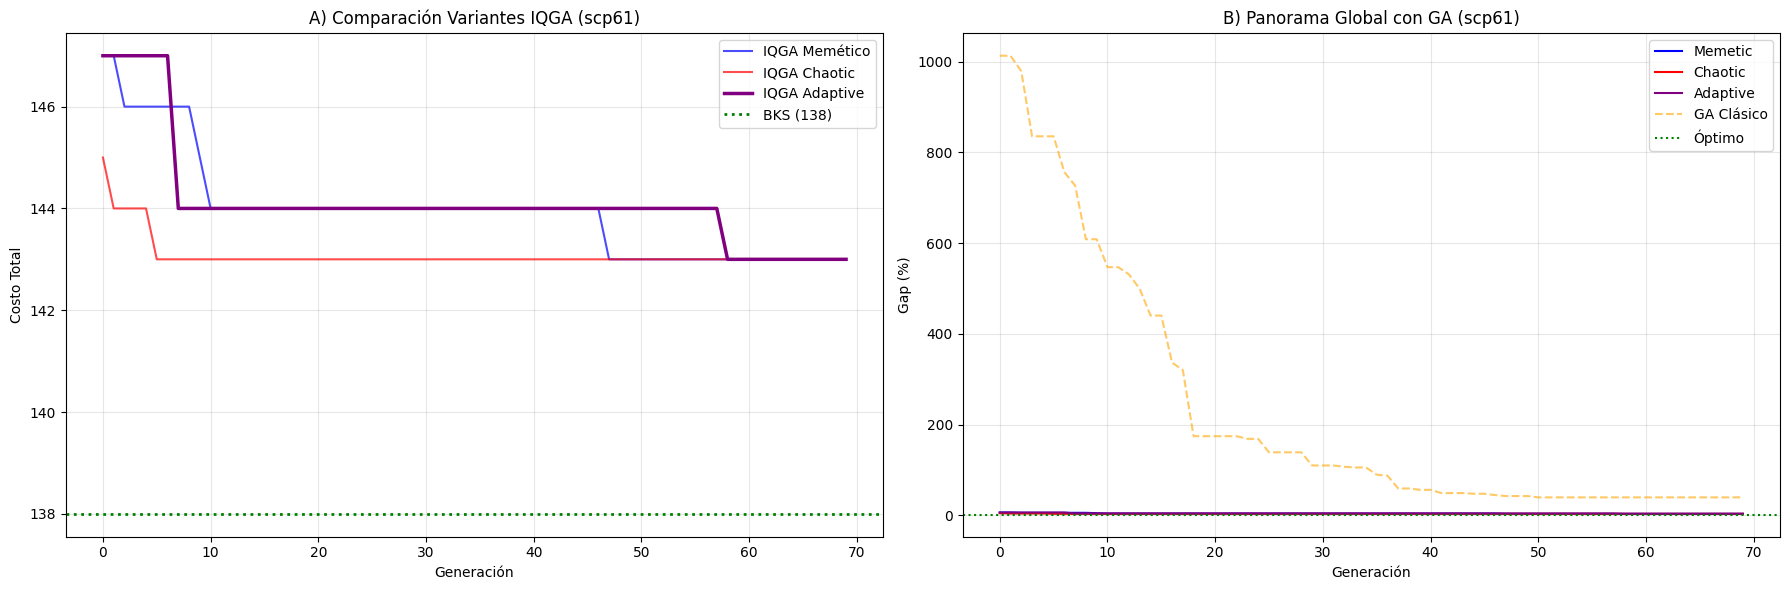

RESULTADOS FINALES PARA scp61:
   Memetic Gap:  3.62%  (Costo: 143.0)
   Chaotic Gap:  3.62%  (Costo: 143.0)
   Adaptive Gap: 3.62%  (Costo: 143.0)
   GA Gap:       39.86%  (Costo: 193.0)
--------------------------------------------------------------------------------
Descargando scpa1.txt desde OR-Library...
Instancia 'scpa1.txt' cargada: 300 filas x 3000 columnas.

Procesando: scpa1 (300x3000) | BKS: 253
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 261.00
   >>> Nuevo Récord: 259.00 (Gen 0)
   >>> Nuevo Récord: 257.00 (Gen 4)
   >>> Nuevo Récord: 256.00 (Gen 6)
Gen 10: 256.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 256.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 255.00 (Gen 22)
   [!] Estancamiento. Perturbando contexto...
Gen 30: 255.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 255.00
   [!] Estancamiento. P

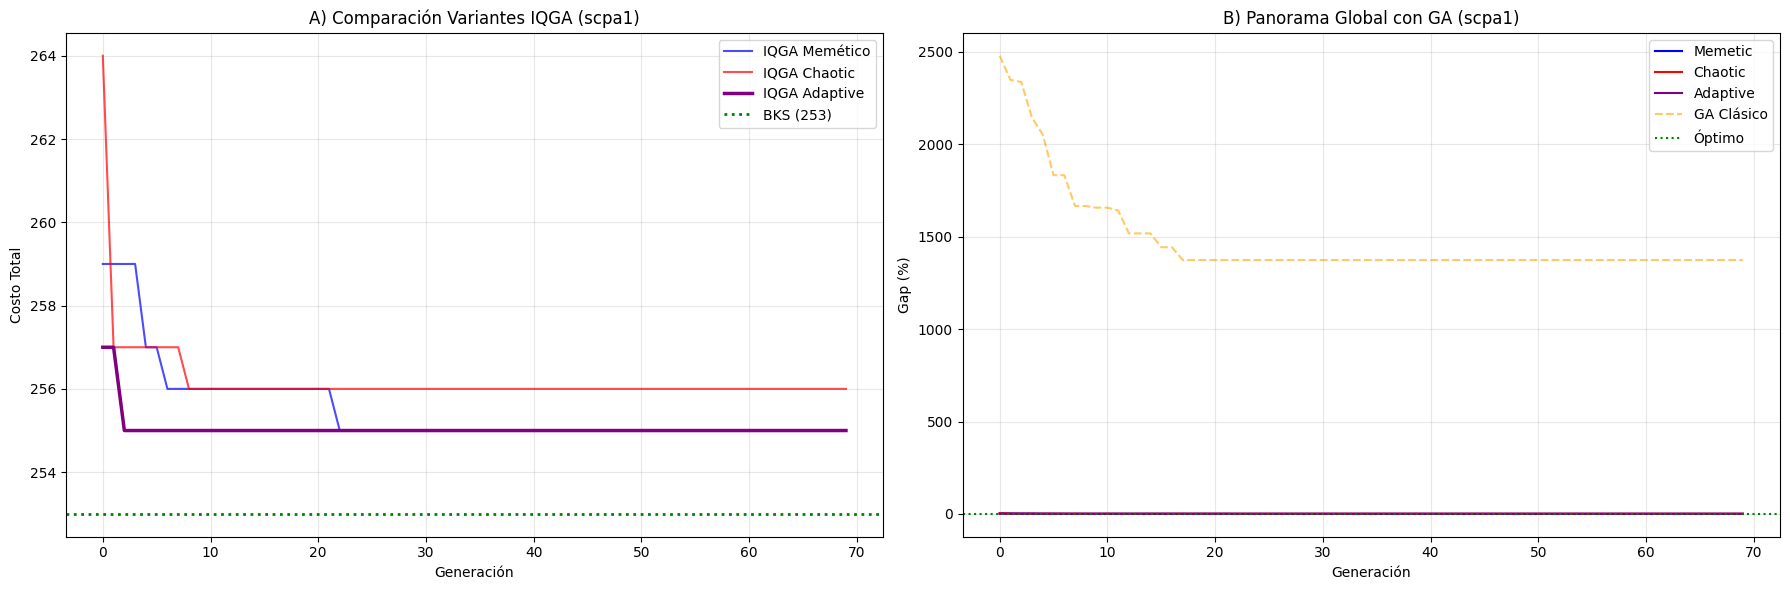

RESULTADOS FINALES PARA scpa1:
   Memetic Gap:  0.79%  (Costo: 255.0)
   Chaotic Gap:  1.19%  (Costo: 256.0)
   Adaptive Gap: 0.79%  (Costo: 255.0)
   GA Gap:       1373.91%  (Costo: 3729.0)
--------------------------------------------------------------------------------
Descargando scpa5.txt desde OR-Library...
Instancia 'scpa5.txt' cargada: 300 filas x 3000 columnas.

Procesando: scpa5 (300x3000) | BKS: 236
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 242.00
   >>> Nuevo Récord: 241.00 (Gen 0)
   >>> Nuevo Récord: 240.00 (Gen 1)
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 239.00 (Gen 7)
Gen 10: 239.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 238.00 (Gen 14)
   [!] Estancamiento. Perturbando contexto...
Gen 20: 238.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 238.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando c

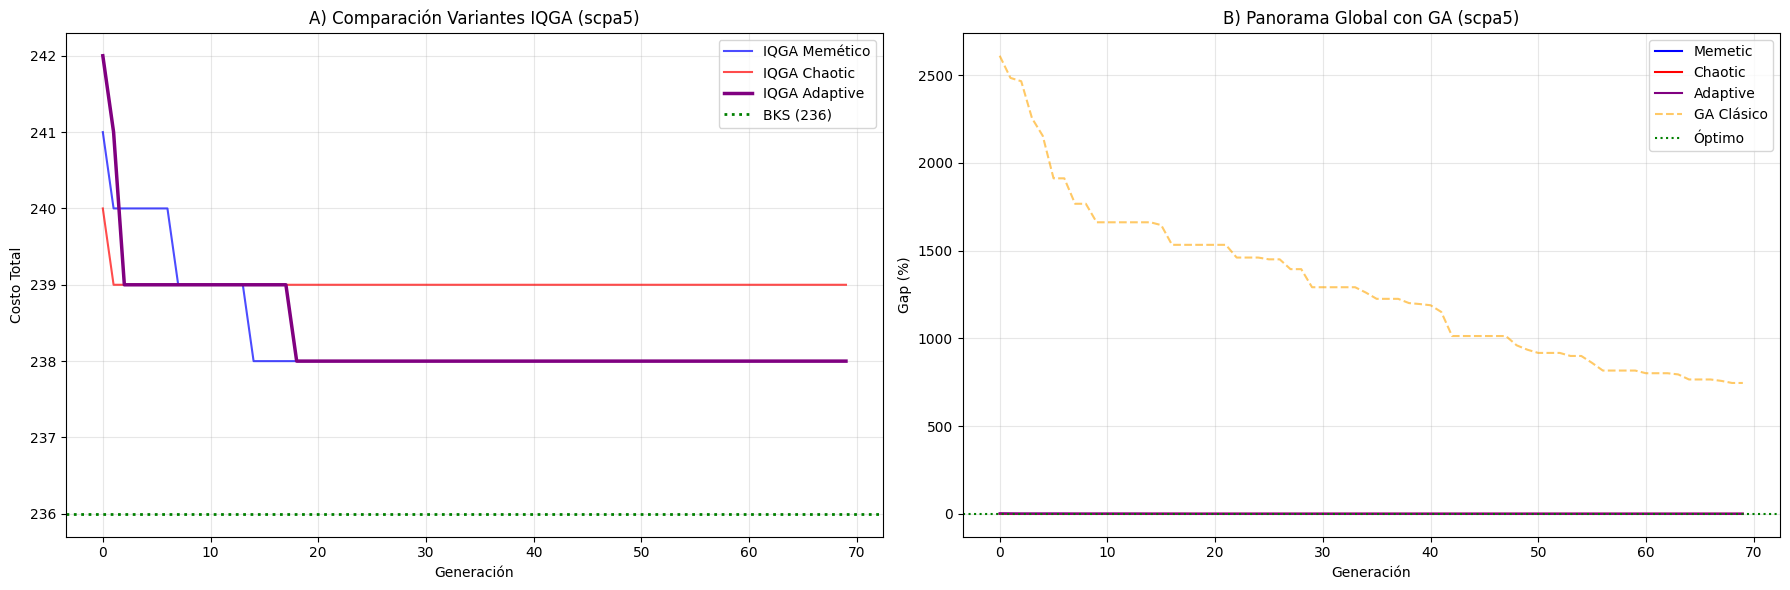

RESULTADOS FINALES PARA scpa5:
   Memetic Gap:  0.85%  (Costo: 238.0)
   Chaotic Gap:  1.27%  (Costo: 239.0)
   Adaptive Gap: 0.85%  (Costo: 238.0)
   GA Gap:       746.19%  (Costo: 1997.0)
--------------------------------------------------------------------------------
Descargando scpb1.txt desde OR-Library...
Instancia 'scpb1.txt' cargada: 300 filas x 3000 columnas.

Procesando: scpb1 (300x3000) | BKS: 69
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 72.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 71.00 (Gen 6)
Gen 10: 71.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 71.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 71.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 71.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...

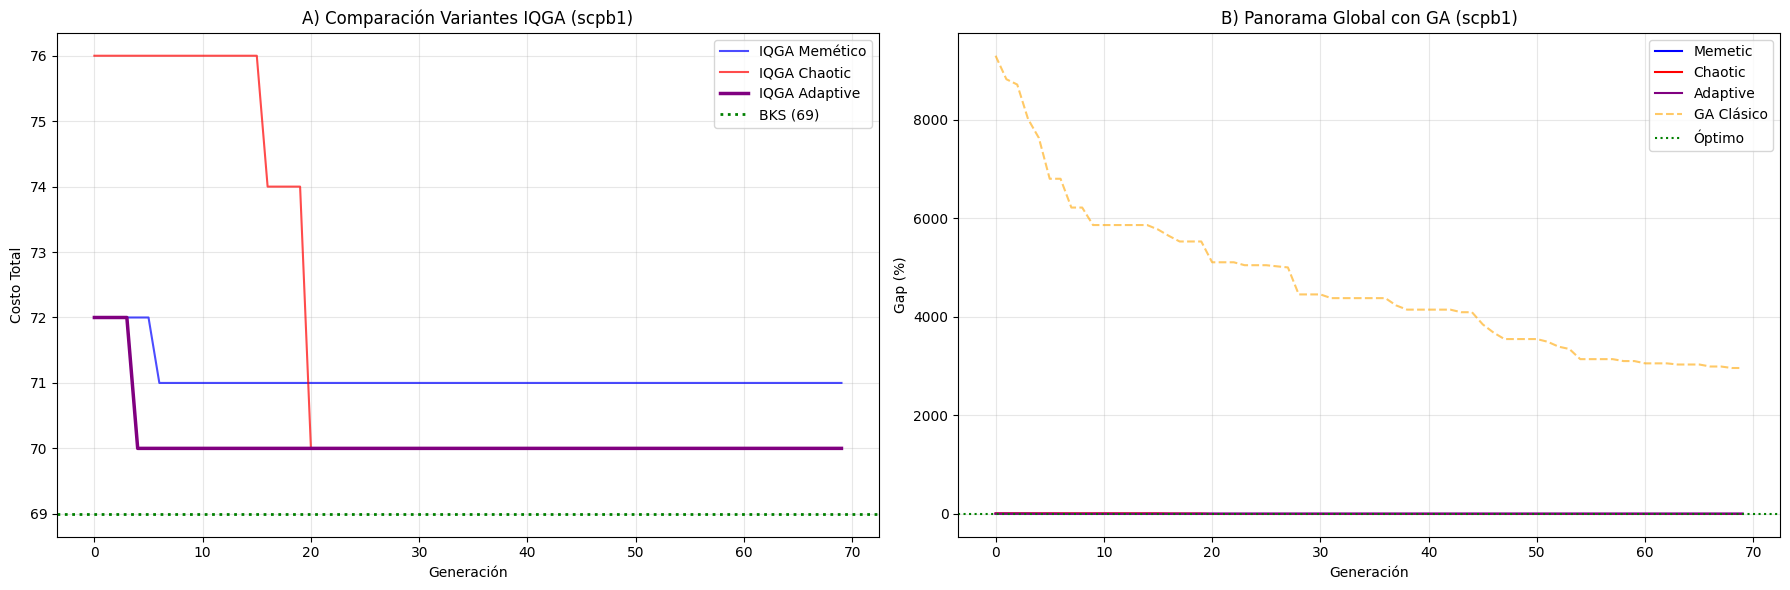

RESULTADOS FINALES PARA scpb1:
   Memetic Gap:  2.90%  (Costo: 71.0)
   Chaotic Gap:  1.45%  (Costo: 70.0)
   Adaptive Gap: 1.45%  (Costo: 70.0)
   GA Gap:       2959.42%  (Costo: 2111.0)
--------------------------------------------------------------------------------
Descargando scpb5.txt desde OR-Library...
Instancia 'scpb5.txt' cargada: 300 filas x 3000 columnas.

Procesando: scpb5 (300x3000) | BKS: 72
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 76.00
   >>> Nuevo Récord: 75.00 (Gen 1)
   >>> Nuevo Récord: 73.00 (Gen 4)
   [!] Estancamiento. Perturbando contexto...
Gen 10: 73.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 73.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 73.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 73.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estan

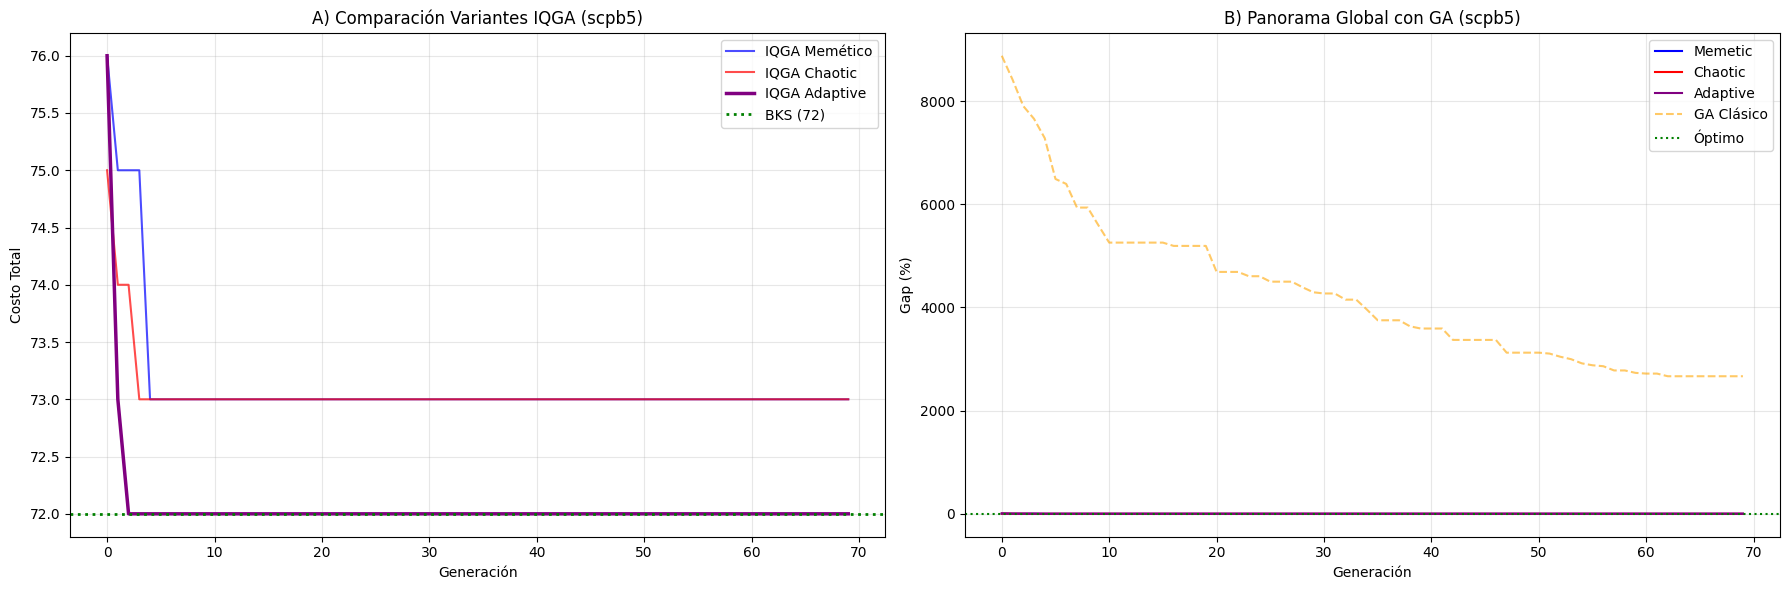

RESULTADOS FINALES PARA scpb5:
   Memetic Gap:  1.39%  (Costo: 73.0)
   Chaotic Gap:  1.39%  (Costo: 73.0)
   Adaptive Gap: 0.00%  (Costo: 72.0)
   GA Gap:       2666.67%  (Costo: 1992.0)
--------------------------------------------------------------------------------
Descargando scpc1.txt desde OR-Library...
Instancia 'scpc1.txt' cargada: 400 filas x 4000 columnas.

Procesando: scpc1 (400x4000) | BKS: 227
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 237.00
   >>> Nuevo Récord: 236.00 (Gen 2)
   >>> Nuevo Récord: 233.00 (Gen 3)
   >>> Nuevo Récord: 232.00 (Gen 7)
Gen 10: 232.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 232.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 231.00 (Gen 23)
   [!] Estancamiento. Perturbando contexto...
Gen 30: 231.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 231.00
   [!] Estancamiento. P

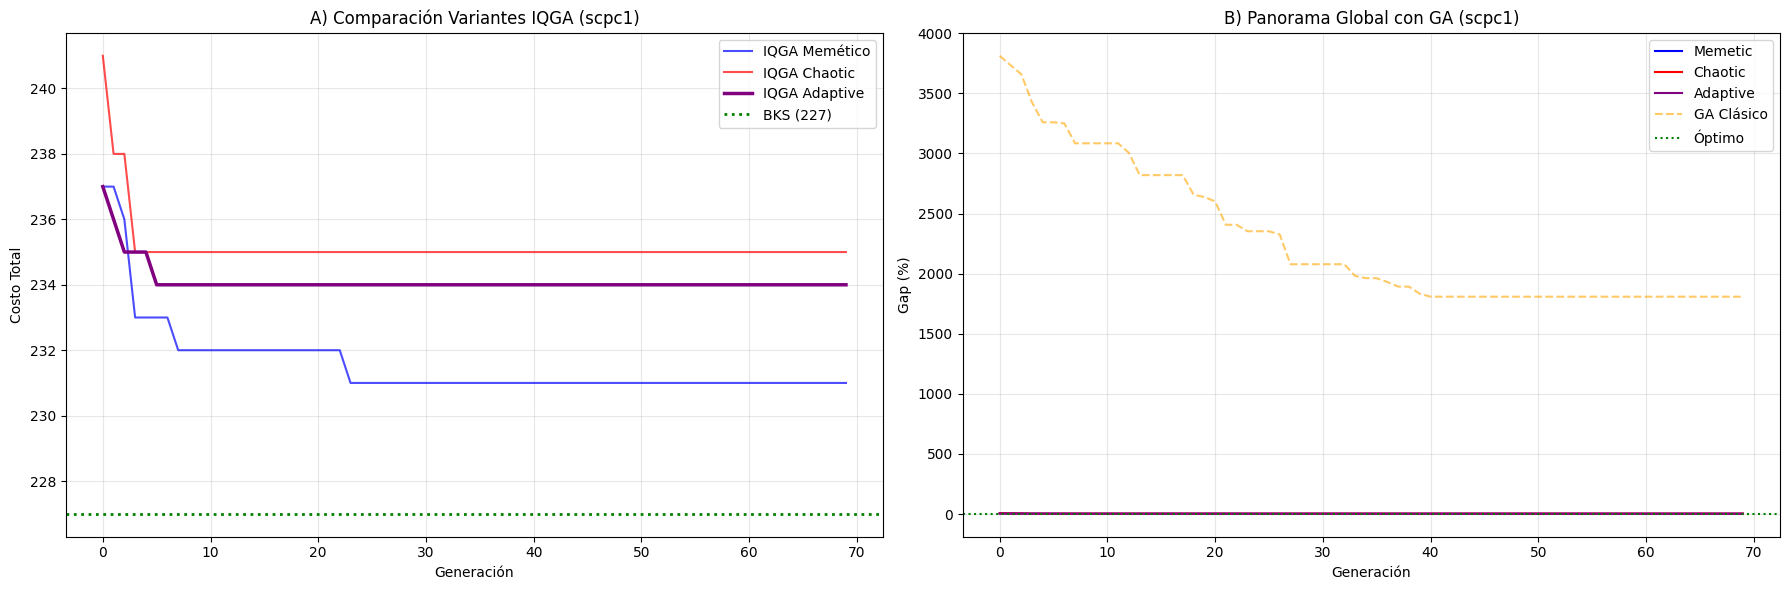

RESULTADOS FINALES PARA scpc1:
   Memetic Gap:  1.76%  (Costo: 231.0)
   Chaotic Gap:  3.52%  (Costo: 235.0)
   Adaptive Gap: 3.08%  (Costo: 234.0)
   GA Gap:       1808.37%  (Costo: 4332.0)
--------------------------------------------------------------------------------
Descargando scpc5.txt desde OR-Library...
Instancia 'scpc5.txt' cargada: 400 filas x 4000 columnas.

Procesando: scpc5 (400x4000) | BKS: 215
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 222.00
   >>> Nuevo Récord: 221.00 (Gen 0)
   [!] Estancamiento. Perturbando contexto...
Gen 10: 221.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 221.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 221.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 220.00 (Gen 38)
Gen 40: 220.00
   [!] Estancamiento. Perturbando contexto...


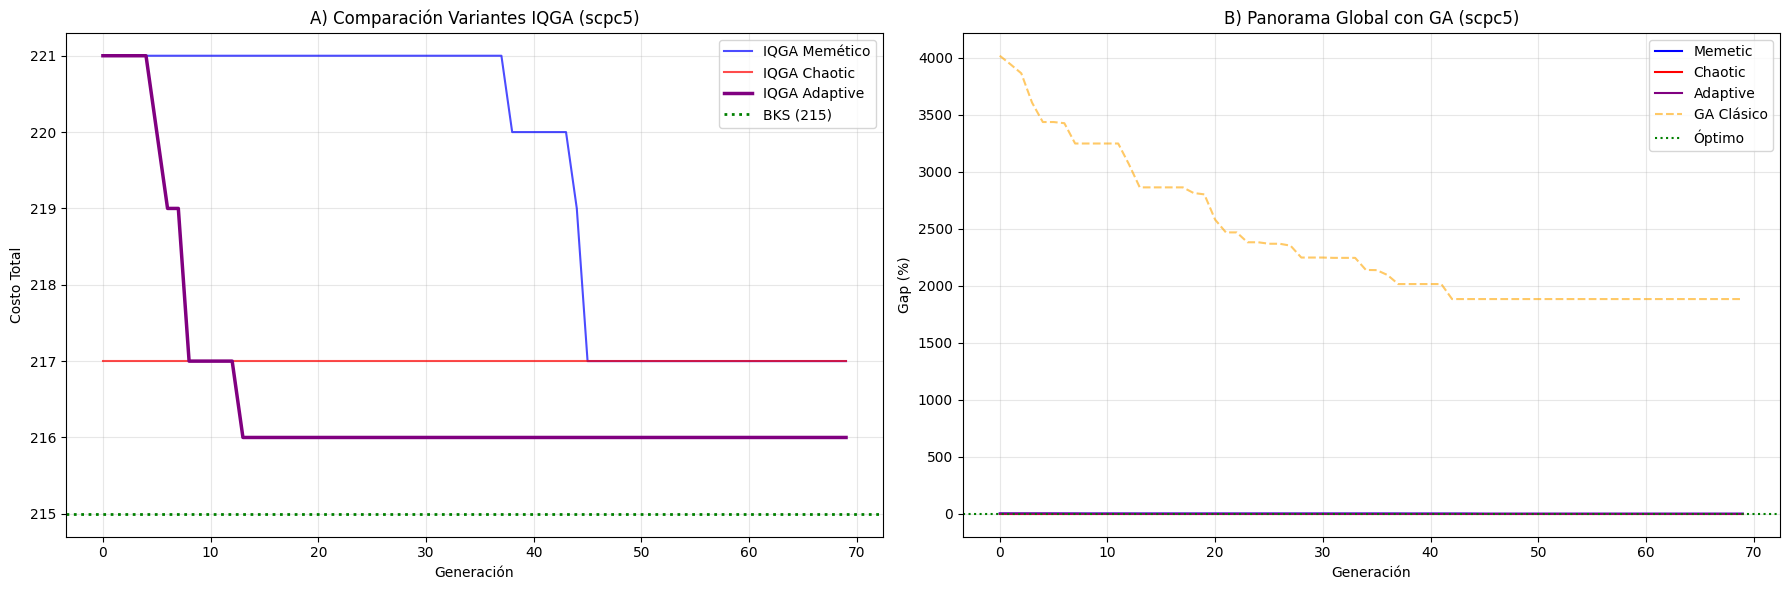

RESULTADOS FINALES PARA scpc5:
   Memetic Gap:  0.93%  (Costo: 217.0)
   Chaotic Gap:  0.93%  (Costo: 217.0)
   Adaptive Gap: 0.47%  (Costo: 216.0)
   GA Gap:       1883.72%  (Costo: 4265.0)
--------------------------------------------------------------------------------

RESULTADOS FINALES


,Instancia,BKS,Memetic Gap%,Chaotic Gap%,Adaptive Gap%,GA Gap%,Ganador
0,scp41,429,0.47,0.93,0.70,27.04,Memetic
1,scp49,641,2.96,2.50,2.50,79.25,Chaotic
2,scp53,226,1.77,1.33,2.21,790.71,Chaotic
3,scp57,293,1.02,4.10,4.44,526.96,Memetic
4,scp61,138,3.62,3.62,3.62,39.86,Memetic
5,scpa1,253,0.79,1.19,0.79,1373.91,Memetic
6,scpa5,236,0.85,1.27,0.85,746.19,Memetic
7,scpb1,69,2.90,1.45,1.45,2959.42,Chaotic
8,scpb5,72,1.39,1.39,0.00,2666.67,Adaptive
9,scpc1,227,1.76,3.52,3.08,1808.37,Memetic



Estadísticas Globales:
Promedio Gap Memético:  1.68%
Promedio Gap Chaotic:   2.02%
Promedio Gap Adaptive:  1.83%
Promedio Gap GA:        1172.92%


In [ ]:
SEED = 1764318086
INSTANCIAS_OBJETIVO = ['scp41', 'scp49', 'scp53', 'scp57', 'scp61',
                       'scpa1','scpa5','scpb1','scpb5','scpc1', 'scpc5',]
BASE_URL = "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/"

# Contenedor de resultados
resultados_globales = []

print(f"Iniciando Benchmark con SEED={SEED}")
print(f"Instancias: {len(INSTANCIAS_OBJETIVO)} archivos a procesar")
print("="*80)

for nombre_instancia in INSTANCIAS_OBJETIVO:
    url = f"{BASE_URL}{nombre_instancia}.txt"
    try:
        instancia = load_or_library_instance(url)
    except Exception as e:
        print(f"Error cargando {nombre_instancia}: {e}")
        continue

    # 2. Obtener BKS
    bks_info = OPT_SCP.get(nombre_instancia, None)
    bks = bks_info["value"] if bks_info else None

    print(f"\nProcesando: {nombre_instancia} ({instancia.n_elems}x{instancia.n_sets}) | BKS: {bks}")

    n_groups = 20 if instancia.n_sets > 2000 else 10

    # --- EJECUCIÓN 1: IQGA MEMÉTICO (V4) ---
    start = time.time()
    cost_mem, sol_mem, hist_mem = run_memetic_iqga(instancia, n_groups=n_groups, generations=70, shots=512, seed=SEED)
    time_mem = time.time() - start
    print_solution_details(sol_mem, instancia, "IQGA MEMÉTICO")

    # --- EJECUCIÓN 2: IQGA CHAOTIC (V5) ---
    start = time.time()
    cost_ch, sol_ch, hist_ch = run_chaotic_iqga(instancia, n_groups=n_groups, generations=70, shots=512, seed=SEED)
    time_ch = time.time() - start
    print_solution_details(sol_ch, instancia, "IQGA CHAOTIC")

    # --- EJECUCIÓN 3: IQGA ADAPTIVE (V6 - Híbrido) ---
    start = time.time()
    cost_ada, sol_ada, hist_ada = run_adaptive_iqga(instancia, n_groups=n_groups, generations=70, shots=512, seed=SEED)
    time_ada = time.time() - start
    print_solution_details(sol_ada, instancia, "IQGA ADAPTIVE")
    # --- EJECUCIÓN 4: GA CLÁSICO (Baseline) ---
    start = time.time()
    cost_ga, hist_ga = run_classical_ga_sparse(instancia, pop_size=50, generations=70, seed=SEED)
    time_ga = time.time() - start

    # --- CÁLCULO DE GAPS ---
    gap_mem = get_gap(cost_mem, bks)
    gap_ch = get_gap(cost_ch, bks)
    gap_ada = get_gap(cost_ada, bks)
    gap_ga = get_gap(cost_ga, bks)

    # Determinar ganador
    costs = {"Memetic": cost_mem, "Chaotic": cost_ch, "Adaptive": cost_ada, "GA": cost_ga}
    winner = min(costs, key=costs.get)

    # Registrar Resultados
    res = {
        "Instancia": nombre_instancia,
        "BKS": bks,
        "Memetic Gap%": round(gap_mem, 2),
        "Chaotic Gap%": round(gap_ch, 2),
        "Adaptive Gap%": round(gap_ada, 2),
        "GA Gap%": round(gap_ga, 2),
        "Ganador": winner
    }
    resultados_globales.append(res)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    ax1.plot(hist_mem, label='IQGA Memético', color='blue', linewidth=1.5, alpha=0.7)
    ax1.plot(hist_ch, label='IQGA Chaotic', color='red', linewidth=1.5, alpha=0.7)
    ax1.plot(hist_ada, label='IQGA Adaptive', color='purple', linewidth=2.5)
    if bks:
        ax1.axhline(y=bks, color='green', linestyle=':', label=f'BKS ({bks})', linewidth=2)

    ax1.set_title(f"A) Comparación Variantes IQGA ({nombre_instancia})")
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Costo Total")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if bks:
        # Usamos Gaps para normalizar
        gaps_mem = [get_gap(c, bks) for c in hist_mem]
        gaps_ch = [get_gap(c, bks) for c in hist_ch]
        gaps_ada = [get_gap(c, bks) for c in hist_ada]
        gaps_ga = [get_gap(c, bks) for c in hist_ga]

        ax2.plot(gaps_mem, label='Memetic', color='blue')
        ax2.plot(gaps_ch, label='Chaotic', color='red')
        ax2.plot(gaps_ada, label='Adaptive', color='purple')
        ax2.plot(gaps_ga, label='GA Clásico', color='orange', linestyle='--', alpha=0.6)
        ax2.axhline(y=0, color='green', linestyle=':', label='Óptimo')
        ax2.set_ylabel("Gap (%)")
    else:
        ax2.plot(hist_mem, label='Memetic', color='blue')
        ax2.plot(hist_ch, label='Chaotic', color='red')
        ax2.plot(hist_ada, label='Adaptive', color='purple')
        ax2.plot(hist_ga, label='GA Clásico', color='orange', linestyle='--')
        ax2.set_ylabel("Costo")

    ax2.set_title(f"B) Panorama Global con GA ({nombre_instancia})")
    ax2.set_xlabel("Generación")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"RESULTADOS FINALES PARA {nombre_instancia}:")
    print(f"   Memetic Gap:  {gap_mem:.2f}%  (Costo: {cost_mem})")
    print(f"   Chaotic Gap:  {gap_ch:.2f}%  (Costo: {cost_ch})")
    print(f"   Adaptive Gap: {gap_ada:.2f}%  (Costo: {cost_ada})")
    print(f"   GA Gap:       {gap_ga:.2f}%  (Costo: {cost_ga})")
    print("-" * 80)


df_final = pd.DataFrame(resultados_globales)

print("\nRESULTADOS FINALES")
print("="*90)
try:
    from IPython.display import display
    display(df_final)
except:
    print(df_final.to_string())

print("\nEstadísticas Globales:")
print(f"Promedio Gap Memético:  {df_final['Memetic Gap%'].mean():.2f}%")
print(f"Promedio Gap Chaotic:   {df_final['Chaotic Gap%'].mean():.2f}%")
print(f"Promedio Gap Adaptive:  {df_final['Adaptive Gap%'].mean():.2f}%")
print(f"Promedio Gap GA:        {df_final['GA Gap%'].mean():.2f}%")

# Benchmark de Robustez y Estabilidad (Análisis Estocástico)

## Aviso de Tiempo de Ejecución:
Este análisis de sensibilidad sobre múltiples semillas demora entre 1 y 2 horas en completarse.

Para una prueba rápida: Si se desea validar el funcionamiento sin esperar el tiempo completo, hay que reducir la lista Seeds a un solo elemento (por ejemplo, [1864410066]).

Iniciando Benchmark con para instancia=scp57
Cantidad de Seeds distantas: 5 archivos a procesar
Descargando scp57.txt desde OR-Library...
Instancia 'scp57.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp57 (200x2000) | BKS: 293
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 301.00
   [!] Estancamiento. Perturbando contexto...
   >>> Nuevo Récord: 300.00 (Gen 6)
Gen 10: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 50: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 60: 300.00
   [!] Estancamiento. Perturbando contexto...

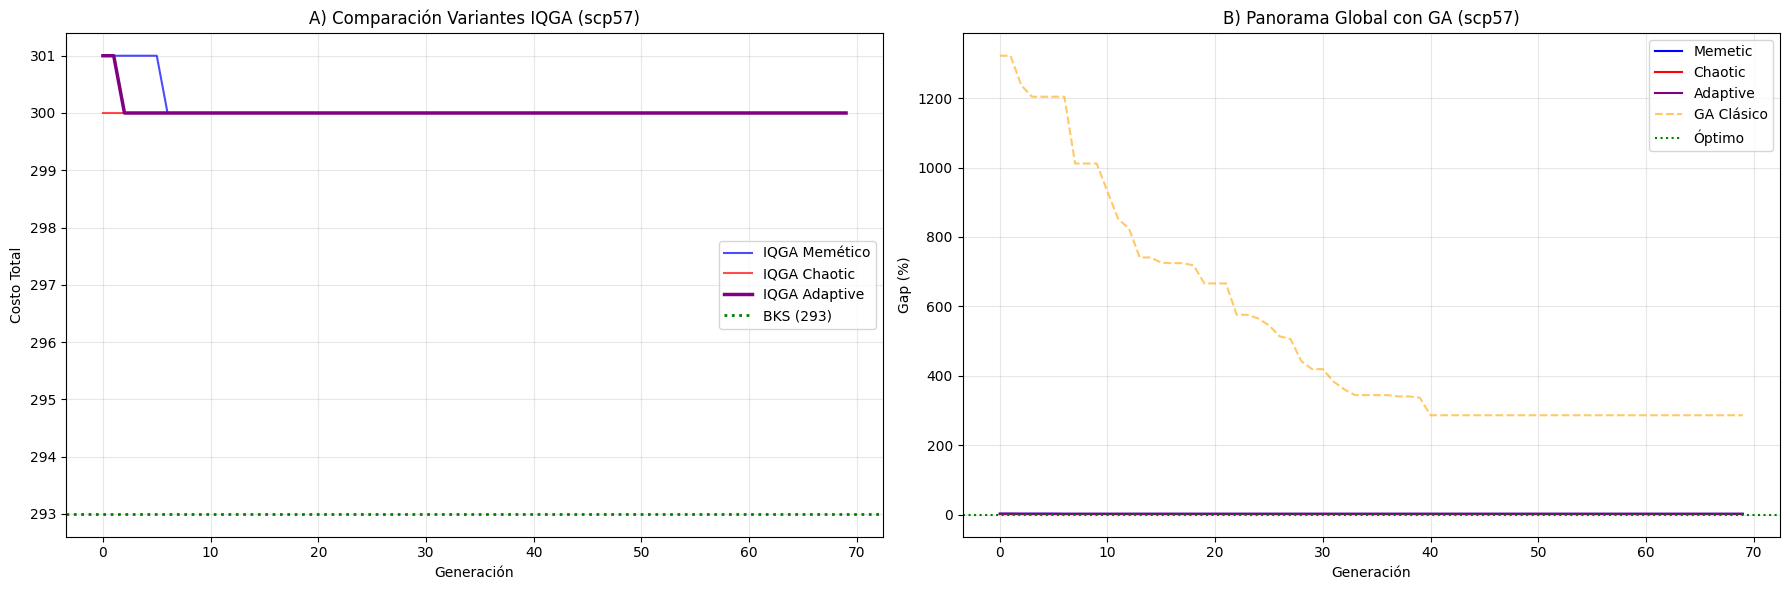

RESULTADOS FINALES PARA scp57:
   Memetic Gap:  2.39%  (Costo: 300.0)
   Chaotic Gap:  2.39%  (Costo: 300.0)
   Adaptive Gap: 2.39%  (Costo: 300.0)
   GA Gap:       286.35%  (Costo: 1132.0)
--------------------------------------------------------------------------------
Instancia 'scp57.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp57 (200x2000) | BKS: 293
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 10: 301.00
   >>> Nuevo Récord: 300.00 (Gen 11)
   [!] Estancamiento. Perturbando contexto...
Gen 20: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 300.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 50: 300.00
   [!] Estancamien

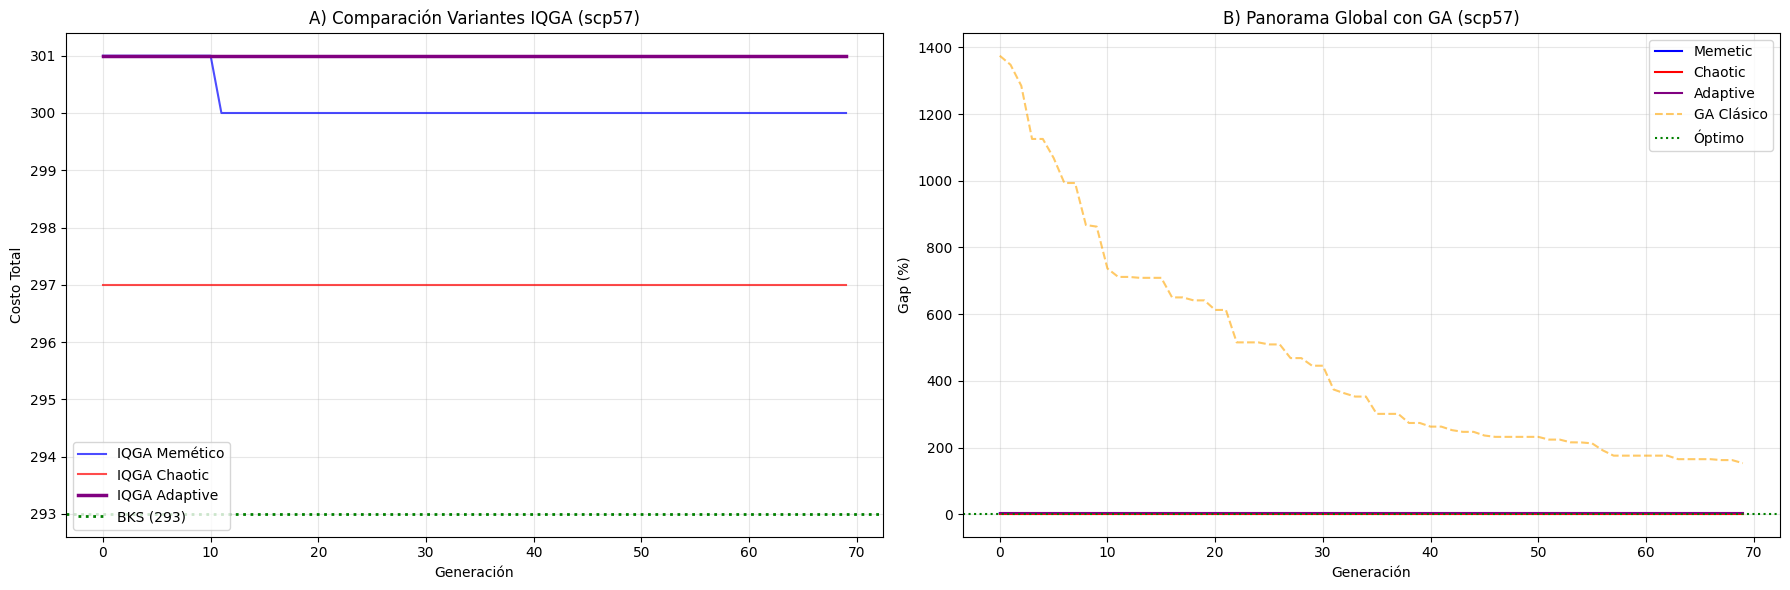

RESULTADOS FINALES PARA scp57:
   Memetic Gap:  2.39%  (Costo: 300.0)
   Chaotic Gap:  1.37%  (Costo: 297.0)
   Adaptive Gap: 2.73%  (Costo: 301.0)
   GA Gap:       153.24%  (Costo: 742.0)
--------------------------------------------------------------------------------
Instancia 'scp57.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp57 (200x2000) | BKS: 293
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 10: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 50: 301.00
   [!] Est

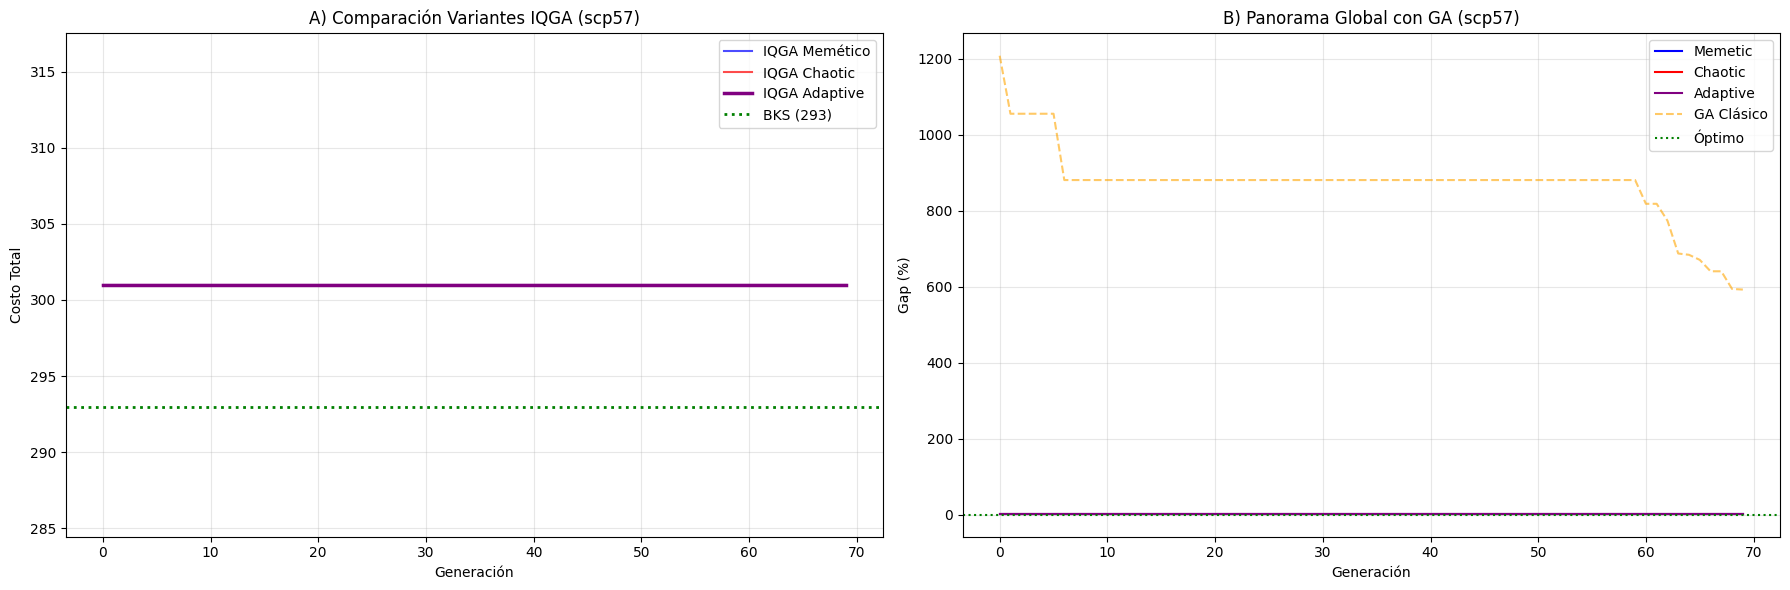

RESULTADOS FINALES PARA scp57:
   Memetic Gap:  2.73%  (Costo: 301.0)
   Chaotic Gap:  2.73%  (Costo: 301.0)
   Adaptive Gap: 2.73%  (Costo: 301.0)
   GA Gap:       592.49%  (Costo: 2029.0)
--------------------------------------------------------------------------------
Instancia 'scp57.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp57 (200x2000) | BKS: 293
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 295.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 10: 295.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 295.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 295.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 295.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 50: 295.00
   [!] Es

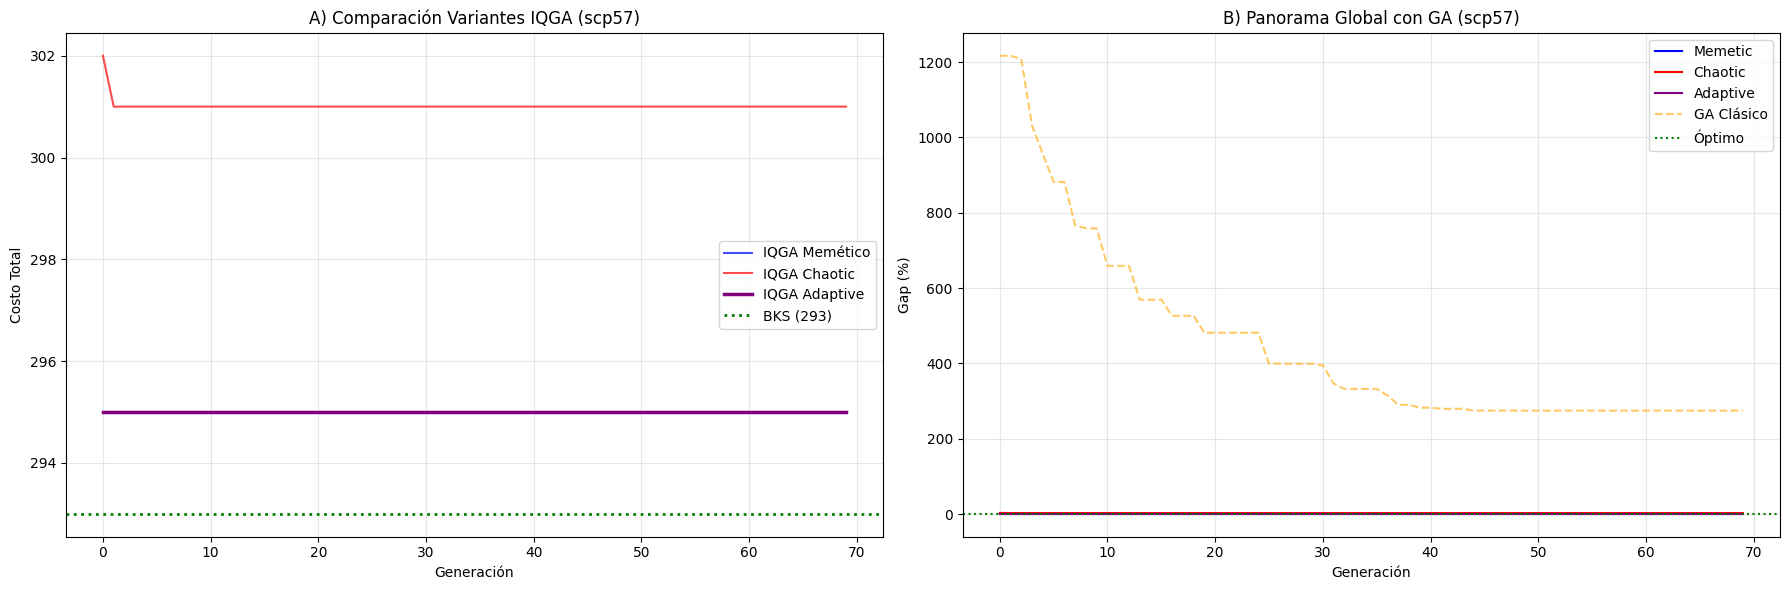

RESULTADOS FINALES PARA scp57:
   Memetic Gap:  0.68%  (Costo: 295.0)
   Chaotic Gap:  2.73%  (Costo: 301.0)
   Adaptive Gap: 0.68%  (Costo: 295.0)
   GA Gap:       274.74%  (Costo: 1098.0)
--------------------------------------------------------------------------------
Instancia 'scp57.txt' cargada: 200 filas x 2000 columnas.

Procesando: scp57 (200x2000) | BKS: 293
--- Memetic IQGA (Quantum + Swap Local Search) ---
Costo Inicial (Optimizado): 304.00
   >>> Nuevo Récord: 302.00 (Gen 0)
   >>> Nuevo Récord: 301.00 (Gen 1)
   [!] Estancamiento. Perturbando contexto...
Gen 10: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 20: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 30: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto...
Gen 40: 301.00
   [!] Estancamiento. Perturbando contexto...
   [!] Estancamiento. Perturbando contexto..

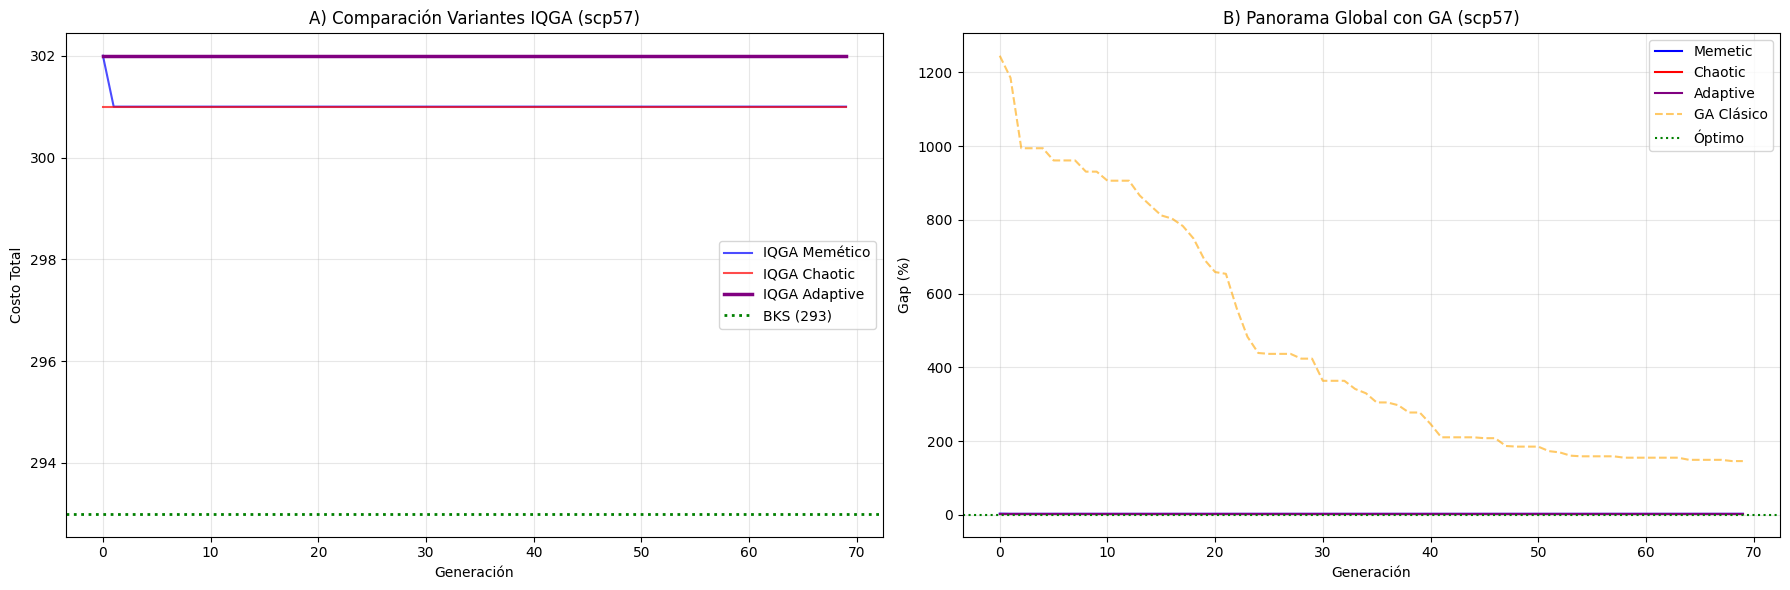

RESULTADOS FINALES PARA scp57:
   Memetic Gap:  2.73%  (Costo: 301.0)
   Chaotic Gap:  2.73%  (Costo: 301.0)
   Adaptive Gap: 3.07%  (Costo: 302.0)
   GA Gap:       145.73%  (Costo: 720.0)
--------------------------------------------------------------------------------

RESULTADOS FINALES


,Instancia,BKS,Memetic Gap%,Chaotic Gap%,Adaptive Gap%,GA Gap%,Ganador
0,scp57,293,2.39,2.39,2.39,286.35,Memetic
1,scp57,293,2.39,1.37,2.73,153.24,Chaotic
2,scp57,293,2.73,2.73,2.73,592.49,Memetic
3,scp57,293,0.68,2.73,0.68,274.74,Memetic
4,scp57,293,2.73,2.73,3.07,145.73,Memetic



Estadísticas Globales:
Promedio Gap Memético:  2.18%
Promedio Gap Chaotic:   2.39%
Promedio Gap Adaptive:  2.32%
Promedio Gap GA:        290.51%


In [ ]:
Seeds = [1864410066, 1264378486, 1661378280, 1714348096, 2744378006]
nombre_instancia = 'scp57'
BASE_URL = "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/"

# Contenedor de resultados
resultados_globales = []

print(f"Iniciando Benchmark con para instancia={nombre_instancia}")
print(f"Cantidad de Seeds distantas: {len(Seeds)} archivos a procesar")
print("="*80)

for SEED in Seeds:
    url = f"{BASE_URL}{nombre_instancia}.txt"
    try:
        instancia = load_or_library_instance(url)
    except Exception as e:
        print(f"Error cargando {nombre_instancia}: {e}")
        continue

    # 2. Obtener BKS
    bks_info = OPT_SCP.get(nombre_instancia, None)
    bks = bks_info["value"] if bks_info else None

    print(f"\nProcesando: {nombre_instancia} ({instancia.n_elems}x{instancia.n_sets}) | BKS: {bks}")

    n_groups = 20 if instancia.n_sets > 2000 else 10

    # --- EJECUCIÓN 1: IQGA MEMÉTICO (V4) ---
    start = time.time()
    cost_mem, sol_mem, hist_mem = run_memetic_iqga(instancia, n_groups=n_groups, generations=70, shots=512, seed=SEED)
    time_mem = time.time() - start
    print_solution_details(sol_mem, instancia, "IQGA MEMÉTICO")

    # --- EJECUCIÓN 2: IQGA CHAOTIC (V5) ---
    start = time.time()
    cost_ch, sol_ch, hist_ch = run_chaotic_iqga(instancia, n_groups=n_groups, generations=70, shots=512, seed=SEED)
    time_ch = time.time() - start
    print_solution_details(sol_ch, instancia, "IQGA CHAOTIC")

    # --- EJECUCIÓN 3: IQGA ADAPTIVE (V6 - Híbrido) ---
    start = time.time()
    cost_ada, sol_ada, hist_ada = run_adaptive_iqga(instancia, n_groups=n_groups, generations=70, shots=512, seed=SEED)
    time_ada = time.time() - start
    print_solution_details(sol_ada, instancia, "IQGA ADAPTIVE")
    # --- EJECUCIÓN 4: GA CLÁSICO (Baseline) ---
    start = time.time()
    cost_ga, hist_ga = run_classical_ga_sparse(instancia, pop_size=50, generations=70, seed=SEED)
    time_ga = time.time() - start

    # --- CÁLCULO DE GAPS ---
    gap_mem = get_gap(cost_mem, bks)
    gap_ch = get_gap(cost_ch, bks)
    gap_ada = get_gap(cost_ada, bks)
    gap_ga = get_gap(cost_ga, bks)

    # Determinar ganador
    costs = {"Memetic": cost_mem, "Chaotic": cost_ch, "Adaptive": cost_ada, "GA": cost_ga}
    winner = min(costs, key=costs.get)

    # Registrar Resultados
    res = {
        "Instancia": nombre_instancia,
        "BKS": bks,
        "Memetic Gap%": round(gap_mem, 2),
        "Chaotic Gap%": round(gap_ch, 2),
        "Adaptive Gap%": round(gap_ada, 2),
        "GA Gap%": round(gap_ga, 2),
        "Ganador": winner
    }
    resultados_globales.append(res)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    ax1.plot(hist_mem, label='IQGA Memético', color='blue', linewidth=1.5, alpha=0.7)
    ax1.plot(hist_ch, label='IQGA Chaotic', color='red', linewidth=1.5, alpha=0.7)
    ax1.plot(hist_ada, label='IQGA Adaptive', color='purple', linewidth=2.5)
    if bks:
        ax1.axhline(y=bks, color='green', linestyle=':', label=f'BKS ({bks})', linewidth=2)

    ax1.set_title(f"A) Comparación Variantes IQGA ({nombre_instancia})")
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Costo Total")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if bks:
        # Usamos Gaps para normalizar
        gaps_mem = [get_gap(c, bks) for c in hist_mem]
        gaps_ch = [get_gap(c, bks) for c in hist_ch]
        gaps_ada = [get_gap(c, bks) for c in hist_ada]
        gaps_ga = [get_gap(c, bks) for c in hist_ga]

        ax2.plot(gaps_mem, label='Memetic', color='blue')
        ax2.plot(gaps_ch, label='Chaotic', color='red')
        ax2.plot(gaps_ada, label='Adaptive', color='purple')
        ax2.plot(gaps_ga, label='GA Clásico', color='orange', linestyle='--', alpha=0.6)
        ax2.axhline(y=0, color='green', linestyle=':', label='Óptimo')
        ax2.set_ylabel("Gap (%)")
    else:
        ax2.plot(hist_mem, label='Memetic', color='blue')
        ax2.plot(hist_ch, label='Chaotic', color='red')
        ax2.plot(hist_ada, label='Adaptive', color='purple')
        ax2.plot(hist_ga, label='GA Clásico', color='orange', linestyle='--')
        ax2.set_ylabel("Costo")

    ax2.set_title(f"B) Panorama Global con GA ({nombre_instancia})")
    ax2.set_xlabel("Generación")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"RESULTADOS FINALES PARA {nombre_instancia}:")
    print(f"   Memetic Gap:  {gap_mem:.2f}%  (Costo: {cost_mem})")
    print(f"   Chaotic Gap:  {gap_ch:.2f}%  (Costo: {cost_ch})")
    print(f"   Adaptive Gap: {gap_ada:.2f}%  (Costo: {cost_ada})")
    print(f"   GA Gap:       {gap_ga:.2f}%  (Costo: {cost_ga})")
    print("-" * 80)


df_final = pd.DataFrame(resultados_globales)

print("\nRESULTADOS FINALES")
print("="*90)
try:
    from IPython.display import display
    display(df_final)
except:
    print(df_final.to_string())

print("\nEstadísticas Globales:")
print(f"Promedio Gap Memético:  {df_final['Memetic Gap%'].mean():.2f}%")
print(f"Promedio Gap Chaotic:   {df_final['Chaotic Gap%'].mean():.2f}%")
print(f"Promedio Gap Adaptive:  {df_final['Adaptive Gap%'].mean():.2f}%")
print(f"Promedio Gap GA:        {df_final['GA Gap%'].mean():.2f}%")

# 5. Conclusiones y Análisis de Resultados

El presente trabajo evaluó el desempeño de un Algoritmo Genético Cuántico Mejorado (IQGA) aplicado al Set Covering Problem (SCP), utilizando un conjunto representativo de instancias de la OR-Library con dimensiones de hasta 400 filas y 4000 columnas. El estudio se dividió en dos fases: una evaluación de rendimiento general sobre 11 instancias y un análisis de robustez estocástica con múltiples semillas sobre una instancia crítica (scp57).

A continuación, se detallan los hallazgos principales.

## 5.1. Supremacía del Enfoque Híbrido sobre el Clásico

El resultado más contundente del estudio es la superioridad absoluta del enfoque IQGA híbrido frente al Algoritmo Genético (GA) clásico utilizado como línea base.
- Brecha de Calidad (Gap): En el benchmark general, las variantes del IQGA mantuvieron un Gap promedio (distancia al óptimo) de entre 1.68% y 2.02%. En contraste, el GA clásico presentó un Gap promedio del 1172.92%.

- Ineficacia de la Evolución Pura: Los resultados demuestran que, para problemas con restricciones estrictas como el SCP, la evolución ciega (GA estándar) es incapaz de mantener la factibilidad. El éxito del IQGA valida la arquitectura propuesta: una representación cuántica probabilística guiada por mecanismos de Reparación Estocástica y Búsqueda Local (Swap).

## 5.2. Comparación de Estrategias: Memético, Caótico y Adaptativo

Se contrastaron tres estrategias de actualización de los ángulos de rotación (θ):

### 1. IQGA Memético (El más consistente):
Resultó ser la variante más equilibrada, obteniendo el menor Gap promedio global (1.68%). Fue el ganador en la mayoría de las instancias (ej. scp41, scp57, scp61), demostrando que una perturbación controlada es ideal para refinar soluciones sin destruir el aprendizaje previo.

### 2. IQGA Adaptativo (Híbrido):
Con un Gap promedio de 1.83%, mostró su potencial al lograr el óptimo global (Gap 0.00%) en la instancia scpb5. Sin embargo, en instancias muy complejas, el mecanismo de cambio de estado a veces impidió la convergencia profunda que logra el memético puro.

### 3. IQGA Caótico (Alta Entropía):
Aunque tuvo la mayor varianza (Gap promedio 2.02%), fue crucial para resolver instancias rugosas donde otros fallaron, ganando en scp49 y scpb1.

## 5.3. Análisis de Robustez y Estabilidad Estocástica

Para validar la confiabilidad del algoritmo, se sometió a la instancia scp57 (BKS: 293) a pruebas de estrés con 5 semillas aleatorias distintas.

- Estabilidad frente al Azar: El IQGA Memético demostró una alta estabilidad, con sus resultados oscilando en un rango estrecho entre 0.68% y 2.73%. Esto confirma que el algoritmo converge a una "zona de calidad" consistentemente, independientemente de la inicialización aleatoria.

- El Fenómeno del "Golden Run": Se observó que el azar juega un papel constructivo. En una de las ejecuciones (Seed 3), la combinación de exploración cuántica y búsqueda local logró un costo de 295 (Gap 0.68%), muy cercano al óptimo teórico.

- Contraste con GA: En las mismas pruebas, el GA clásico mostró una inestabilidad extrema, con errores fluctuando entre 145% y 592%, confirmando su dependencia crítica de la población inicial.

## 5.4. Escalabilidad mediante Simulación MPS

Un logro técnico clave fue la superación de la barrera de memoria en la simulación cuántica. La implementación de la simulación por bloques mediante Matrix Product States (MPS) permitió manejar instancias de 4000 variables (qubits) (scpc1, scpc5) en tiempos computacionales viables. Los resultados competitivos en la Serie C (Gaps < 2%) validan que la descomposición del entrelazamiento en grupos locales es una estrategia efectiva para escalar algoritmos cuánticos variacionales.

## 5.5. Conclusión Final

La investigación concluye que el IQGA Memético con simulación MPS es la configuración más recomendable para el Set Covering Problem. La arquitectura híbrida propuesta transforma la incertidumbre cuántica en una ventaja de exploración, permitiendo encontrar soluciones cuasi-óptimas de manera robusta y escalable, superando por varios órdenes de magnitud a los enfoques evolutivos clásicos sin reparación inteligente.